# **Data Loading: Dataset downloaded on PC**

In [ ]:
from google.colab import files

data = files.upload()

Saving mental-heath-in-tech-2016_20161114.csv to mental-heath-in-tech-2016_20161114.csv


In [ ]:
pip install mlxtend

# **Data Preprocessing: Exploration, Cleaning/Wrangling, and Feature Engineering**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

from sklearn.preprocessing import OrdinalEncoder


In [ ]:
df = pd.read_csv("mental-heath-in-tech-2016_20161114.csv")
df.head(5)

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Lead,Sometimes
4,0,6-25,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes


In [ ]:
df.shape

(1433, 63)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 63 columns):
 #   Column                                                                                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                                                                                            --------------  -----  
 0   Are you self-employed?                                                                                                                                                            1433 non-null   int64  
 1   How many employees does your company or organization have?                                                                                                                        1146 non-null   object 
 2   Is your employer primarily a tech company/organization?     

In [ ]:
# Select categorical columns
cat_cols = df.select_dtypes(include="object").columns

# Convert to lowercase and remove spaces
for col in cat_cols:
     df[col] = df[col].astype(str).str.strip().str.lower()

In [ ]:
df.head()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,not eligible for coverage / n/a,nan,no,no,i don't know,very easy,...,not applicable to me,not applicable to me,39,male,united kingdom,nan,united kingdom,nan,back-end developer,sometimes
1,0,6-25,1.0,NaN,no,yes,yes,yes,yes,somewhat easy,...,rarely,sometimes,29,male,united states of america,illinois,united states of america,illinois,back-end developer|front-end developer,never
2,0,6-25,1.0,NaN,no,nan,no,no,i don't know,neither easy nor difficult,...,not applicable to me,not applicable to me,38,male,united kingdom,nan,united kingdom,nan,back-end developer,always
3,1,nan,NaN,NaN,nan,nan,nan,nan,nan,nan,...,sometimes,sometimes,43,male,united kingdom,nan,united kingdom,nan,supervisor/team lead,sometimes
4,0,6-25,0.0,1.0,yes,yes,no,no,no,neither easy nor difficult,...,sometimes,sometimes,43,female,united states of america,illinois,united states of america,illinois,executive leadership|supervisor/team lead|dev ...,sometimes


In [ ]:
df.replace("nan", np.nan, inplace=True)

In [ ]:
# Select categorical columns
cat_cols1 = df.select_dtypes(include="object").columns

for coln in cat_cols1:
    print(coln, df[coln].unique()[:5])

How many employees does your company or organization have? ['26-100' '6-25' nan 'more than 1000' '100-500']
Does your employer provide mental health benefits as part of healthcare coverage? ['not eligible for coverage / n/a' 'no' nan 'yes' "i don't know"]
Do you know the options for mental health care available under your employer-provided coverage? [nan 'yes' 'i am not sure' 'no']
Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)? ['no' 'yes' nan "i don't know"]
Does your employer offer resources to learn more about mental health concerns and options for seeking help? ['no' 'yes' nan "i don't know"]
Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer? ["i don't know" 'yes' nan 'no']
If a mental health issue prompted you to request a medical leave from work, asking for that leave would be: ['very easy' 'somewhat ea

In [ ]:
df.head(5)

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,not eligible for coverage / n/a,NaN,no,no,i don't know,very easy,...,not applicable to me,not applicable to me,39,male,united kingdom,NaN,united kingdom,NaN,back-end developer,sometimes
1,0,6-25,1.0,NaN,no,yes,yes,yes,yes,somewhat easy,...,rarely,sometimes,29,male,united states of america,illinois,united states of america,illinois,back-end developer|front-end developer,never
2,0,6-25,1.0,NaN,no,NaN,no,no,i don't know,neither easy nor difficult,...,not applicable to me,not applicable to me,38,male,united kingdom,NaN,united kingdom,NaN,back-end developer,always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,sometimes,sometimes,43,male,united kingdom,NaN,united kingdom,NaN,supervisor/team lead,sometimes
4,0,6-25,0.0,1.0,yes,yes,no,no,no,neither easy nor difficult,...,sometimes,sometimes,43,female,united states of america,illinois,united states of america,illinois,executive leadership|supervisor/team lead|dev ...,sometimes


In [ ]:
df.isnull().sum()

,0
Are you self-employed?,0
How many employees does your company or organization have?,287
Is your employer primarily a tech company/organization?,287
Is your primary role within your company related to tech/IT?,1170
Does your employer provide mental health benefits as part of healthcare coverage?,287
...,...
What US state or territory do you live in?,593
What country do you work in?,0
What US state or territory do you work in?,582
Which of the following best describes your work position?,0


**Replacing invalid categorical values with NaN.**

In [ ]:
df.replace({
    "i don't know": "unknown",
    "i am not sure": "unknown",
    "maybe/not sure": "unknown"
}, inplace=True)

In [ ]:
df.replace([
    "na", "n/a", "none", "", "unknown","not applicable to me",
    "not eligible for coverage / n/a",
    'n/a (not currently aware)',
    'not applicable to me (i do not have a mental illness)'
], np.nan, inplace=True)

In [ ]:
df.isnull().sum()

,0
Are you self-employed?,0
How many employees does your company or organization have?,287
Is your employer primarily a tech company/organization?,287
Is your primary role within your company related to tech/IT?,1170
Does your employer provide mental health benefits as part of healthcare coverage?,689
...,...
What US state or territory do you live in?,593
What country do you work in?,0
What US state or territory do you work in?,582
Which of the following best describes your work position?,0


**Droping columns with missing value >50%**


In [ ]:
missing_ratio = df.isnull().mean()

# Droping columns with >50% missing values
df = df.loc[:, missing_ratio < 0.5]

In [ ]:
df.shape

(1433, 45)

In [ ]:
df.isnull().sum()

,0
Are you self-employed?,0
How many employees does your company or organization have?,287
Is your employer primarily a tech company/organization?,287
Does your employer provide mental health benefits as part of healthcare coverage?,689
"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",390
Does your employer offer resources to learn more about mental health concerns and options for seeking help?,607
"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",437
Do you think that discussing a mental health disorder with your employer would have negative consequences?,287
Do you think that discussing a physical health issue with your employer would have negative consequences?,287
Would you feel comfortable discussing a mental health disorder with your coworkers?,287


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 45 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   Are you self-employed?                                                                                                                      1433 non-null   int64  
 1   How many employees does your company or organization have?                                                                                  1146 non-null   object 
 2   Is your employer primarily a tech company/organization?                                                                                     1146 non-null   float64
 3   Does your employer provide mental health be

**Detecting range columns and calculating mid point**

In [ ]:
# Detecting range columns

def detect_range_columns(df):
    range_cols = []

    pattern = r'^\s*\d+\s*-\s*\d+\s*$'

    for col in df.columns:
        if df[col].dtype == "object":
            if df[col].astype(str).str.match(pattern).any():
                range_cols.append(col)

    return range_cols

range_cols = detect_range_columns(df)
print("Detected range columns:", range_cols)

Detected range columns: ['How many employees does your company or organization have?']


In [ ]:
def range_to_midpoint(x):
    if isinstance(x, str):
        x = x.strip()

        # numeric range only
        match = re.match(r'^(\d+)\s*-\s*(\d+)$', x)
        if match:
            a, b = match.groups()
            return (float(a) + float(b)) / 2

        # "10+"
        match_plus = re.match(r'^(\d+)\+$', x)
        if match_plus:
            return float(match_plus.group(1)) + 2  # assumption

        # If a number
        if x.isdigit():
            return float(x)

    return np.nan

In [ ]:
df.nunique()

,0
Are you self-employed?,2
How many employees does your company or organization have?,6
Is your employer primarily a tech company/organization?,2
Does your employer provide mental health benefits as part of healthcare coverage?,2
"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",2
Does your employer offer resources to learn more about mental health concerns and options for seeking help?,2
"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",5
Do you think that discussing a mental health disorder with your employer would have negative consequences?,3
Do you think that discussing a physical health issue with your employer would have negative consequences?,3
Would you feel comfortable discussing a mental health disorder with your coworkers?,3


In [ ]:
df.head(5)

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Does your employer provide mental health benefits as part of healthcare coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,no,no,very easy,no,no,maybe,...,NaN,NaN,39,male,united kingdom,NaN,united kingdom,NaN,back-end developer,sometimes
1,0,6-25,1.0,no,yes,yes,somewhat easy,no,no,maybe,...,rarely,sometimes,29,male,united states of america,illinois,united states of america,illinois,back-end developer|front-end developer,never
2,0,6-25,1.0,no,no,no,neither easy nor difficult,maybe,no,maybe,...,NaN,NaN,38,male,united kingdom,NaN,united kingdom,NaN,back-end developer,always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,sometimes,sometimes,43,male,united kingdom,NaN,united kingdom,NaN,supervisor/team lead,sometimes
4,0,6-25,0.0,yes,no,no,neither easy nor difficult,yes,maybe,maybe,...,sometimes,sometimes,43,female,united states of america,illinois,united states of america,illinois,executive leadership|supervisor/team lead|dev ...,sometimes


In [ ]:
for col in range_cols:
    df[col + "_mid"] = df[col].apply(range_to_midpoint)

df.drop(columns=range_cols, inplace=True)

In [ ]:
df.head(5)

,Are you self-employed?,Is your employer primarily a tech company/organization?,Does your employer provide mental health benefits as part of healthcare coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,...,"If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?,How many employees does your company or organization have?_mid
0,0,1.0,NaN,no,no,very easy,no,no,maybe,yes,...,NaN,39,male,united kingdom,NaN,united kingdom,NaN,back-end developer,sometimes,63.0
1,0,1.0,no,yes,yes,somewhat easy,no,no,maybe,yes,...,sometimes,29,male,united states of america,illinois,united states of america,illinois,back-end developer|front-end developer,never,15.5
2,0,1.0,no,no,no,neither easy nor difficult,maybe,no,maybe,maybe,...,NaN,38,male,united kingdom,NaN,united kingdom,NaN,back-end developer,always,15.5
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,sometimes,43,male,united kingdom,NaN,united kingdom,NaN,supervisor/team lead,sometimes,NaN
4,0,0.0,yes,no,no,neither easy nor difficult,yes,maybe,maybe,no,...,sometimes,43,female,united states of america,illinois,united states of america,illinois,executive leadership|supervisor/team lead|dev ...,sometimes,15.5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 45 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   Are you self-employed?                                                                                                                      1433 non-null   int64  
 1   Is your employer primarily a tech company/organization?                                                                                     1146 non-null   float64
 2   Does your employer provide mental health benefits as part of healthcare coverage?                                                           744 non-null    object 
 3   Has your employer ever formally discussed m

**Defining columns to drop base on domain knowledge and exploration**

In [ ]:
# Some could increase model complexity if encoded e.g gender type more than 2 etc

drop_cols = [
    "Why or why not?",
    "Why or why not?.1",
    "What US state or territory do you live in?",
    "What US state or territory do you work in?",
    "What country do you live in?",
    "What is your gender?",
    "Which of the following best describes your work position?",
    "What country do you work in?"
]


df = df.drop(columns=[col for col in drop_cols if col in df.columns])
df.shape

(1433, 37)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 37 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   Are you self-employed?                                                                                                                      1433 non-null   int64  
 1   Is your employer primarily a tech company/organization?                                                                                     1146 non-null   float64
 2   Does your employer provide mental health benefits as part of healthcare coverage?                                                           744 non-null    object 
 3   Has your employer ever formally discussed m

**Imputation of missing data and NaN**

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

In [ ]:
num_df = pd.DataFrame(num_cols, columns=['Numerical_Columns'])
cat_df = pd.DataFrame(cat_cols, columns=['Categorical_Columns'])

num_df = df[num_cols]
num_df.head(5)

,Are you self-employed?,Is your employer primarily a tech company/organization?,Do you have previous employers?,Have you ever sought treatment for a mental health issue from a mental health professional?,What is your age?,How many employees does your company or organization have?_mid
0,0,1.0,1,0,39,63.0
1,0,1.0,1,1,29,15.5
2,0,1.0,1,1,38,15.5
3,1,NaN,1,1,43,NaN
4,0,0.0,1,1,43,15.5


In [ ]:
cat_df = df[cat_cols]
cat_df.head(5)

,Does your employer provide mental health benefits as part of healthcare coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Have your previous employers provided mental health benefits?,...,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?,How willing would you be to share with friends and family that you have a mental illness?,Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?,Do you have a family history of mental illness?,Have you had a mental health disorder in the past?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",Do you work remotely?
0,NaN,no,no,very easy,no,no,maybe,yes,no,"no, none did",...,"no, i don't think they would",somewhat open,no,no,yes,no,yes,NaN,NaN,sometimes
1,no,yes,yes,somewhat easy,no,no,maybe,yes,no,"yes, they all did",...,"no, i don't think they would",somewhat open,no,yes,yes,yes,yes,rarely,sometimes,never
2,no,no,no,neither easy nor difficult,maybe,no,maybe,maybe,no,"no, none did",...,maybe,somewhat open,NaN,no,maybe,no,no,NaN,NaN,always
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,some did,...,maybe,neutral,no,no,yes,yes,yes,sometimes,sometimes,sometimes
4,yes,no,no,neither easy nor difficult,yes,maybe,maybe,no,no,NaN,...,maybe,somewhat open,"yes, i experienced",yes,yes,yes,yes,sometimes,sometimes,sometimes


In [ ]:
# Numerical → BayesianRidge
df[num_cols] = IterativeImputer(BayesianRidge()).fit_transform(df[num_cols])

# Categorical → most frequent
df[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[cat_cols])

In [ ]:
df.head(5)

,Are you self-employed?,Is your employer primarily a tech company/organization?,Does your employer provide mental health benefits as part of healthcare coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,...,Do you have a family history of mental illness?,Have you had a mental health disorder in the past?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,Do you work remotely?,How many employees does your company or organization have?_mid
0,0.0,1.000000,yes,no,no,very easy,no,no,maybe,yes,...,no,yes,no,yes,0.0,sometimes,often,39.0,sometimes,63.00000
1,0.0,1.000000,no,yes,yes,somewhat easy,no,no,maybe,yes,...,yes,yes,yes,yes,1.0,rarely,sometimes,29.0,never,15.50000
2,0.0,1.000000,no,no,no,neither easy nor difficult,maybe,no,maybe,maybe,...,no,maybe,no,no,1.0,sometimes,often,38.0,always,15.50000
3,1.0,0.750071,yes,no,no,somewhat easy,maybe,no,maybe,yes,...,no,yes,yes,yes,1.0,sometimes,sometimes,43.0,sometimes,178.97448
4,0.0,0.000000,yes,no,no,neither easy nor difficult,yes,maybe,maybe,no,...,yes,yes,yes,yes,1.0,sometimes,sometimes,43.0,sometimes,15.50000


In [ ]:
df.tail(5)

,Are you self-employed?,Is your employer primarily a tech company/organization?,Does your employer provide mental health benefits as part of healthcare coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,...,Do you have a family history of mental illness?,Have you had a mental health disorder in the past?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,Do you work remotely?,How many employees does your company or organization have?_mid
1428,1.0,0.769772,yes,no,no,somewhat easy,maybe,no,maybe,yes,...,yes,no,no,no,1.0,sometimes,often,34.0,sometimes,175.870131
1429,1.0,0.721454,yes,no,no,somewhat easy,maybe,no,maybe,yes,...,yes,no,no,yes,0.0,sometimes,often,56.0,sometimes,183.425028
1430,0.0,1.000000,yes,yes,yes,somewhat difficult,maybe,maybe,yes,yes,...,yes,yes,maybe,yes,1.0,rarely,sometimes,52.0,sometimes,300.000000
1431,0.0,0.000000,yes,no,yes,somewhat difficult,maybe,no,maybe,yes,...,yes,maybe,yes,yes,0.0,sometimes,often,30.0,sometimes,300.000000
1432,0.0,1.000000,yes,no,no,very difficult,maybe,no,maybe,maybe,...,yes,yes,yes,no,0.0,sometimes,often,25.0,sometimes,300.000000


In [ ]:
num2_df = pd.DataFrame(num_cols, columns=['Numerical_Columns'])

num2_df = df[num_cols]
num2_df.head(5)

,Are you self-employed?,Is your employer primarily a tech company/organization?,Do you have previous employers?,Have you ever sought treatment for a mental health issue from a mental health professional?,What is your age?,How many employees does your company or organization have?_mid
0,0.0,1.000000,1.0,0.0,39.0,63.00000
1,0.0,1.000000,1.0,1.0,29.0,15.50000
2,0.0,1.000000,1.0,1.0,38.0,15.50000
3,1.0,0.750071,1.0,1.0,43.0,178.97448
4,0.0,0.000000,1.0,1.0,43.0,15.50000


In [ ]:
num2_df.tail(5)

,Are you self-employed?,Is your employer primarily a tech company/organization?,Do you have previous employers?,Have you ever sought treatment for a mental health issue from a mental health professional?,What is your age?,How many employees does your company or organization have?_mid
1428,1.0,0.769772,1.0,1.0,34.0,175.870131
1429,1.0,0.721454,0.0,0.0,56.0,183.425028
1430,0.0,1.000000,1.0,1.0,52.0,300.000000
1431,0.0,0.000000,1.0,0.0,30.0,300.000000
1432,0.0,1.000000,0.0,0.0,25.0,300.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 37 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   Are you self-employed?                                                                                                                      1433 non-null   float64
 1   Is your employer primarily a tech company/organization?                                                                                     1433 non-null   float64
 2   Does your employer provide mental health benefits as part of healthcare coverage?                                                           1433 non-null   object 
 3   Has your employer ever formally discussed m

**Replacing/aligning words correctly**

In [ ]:
df.replace({
    "m": "male",
    'man': "male",
    'woman': "female",
    "f": "female",
    'female assigned at birth':"female",
    "i identify as female.": "female",
    "yes, i experienced": "yes",
    'yes, i think it would': "yes",
    'yes, i observed': "yes",
    'yes, it has': "yes",
    'no, it has not':"no",
    "no, i don't think it would":"no",
    "non-binary": "non-binary",
    "bigender": "non-binary",
    "nonbinary": "non-binary",
    "non binary": "non-binary"
}, inplace=True)

In [ ]:
# Select categorical columns
cat_cols2 = df.select_dtypes(include="object").columns

for coln in cat_cols2:
    print(coln, df[coln].unique()[:5])

Does your employer provide mental health benefits as part of healthcare coverage? ['yes' 'no']
Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)? ['no' 'yes']
Does your employer offer resources to learn more about mental health concerns and options for seeking help? ['no' 'yes']
If a mental health issue prompted you to request a medical leave from work, asking for that leave would be: ['very easy' 'somewhat easy' 'neither easy nor difficult' 'very difficult'
 'somewhat difficult']
Do you think that discussing a mental health disorder with your employer would have negative consequences? ['no' 'maybe' 'yes']
Do you think that discussing a physical health issue with your employer would have negative consequences? ['no' 'maybe' 'yes']
Would you feel comfortable discussing a mental health disorder with your coworkers? ['maybe' 'yes' 'no']
Would you feel comfortable discussing a mental health disorder with yo

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 37 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   Are you self-employed?                                                                                                                      1433 non-null   float64
 1   Is your employer primarily a tech company/organization?                                                                                     1433 non-null   float64
 2   Does your employer provide mental health benefits as part of healthcare coverage?                                                           1433 non-null   object 
 3   Has your employer ever formally discussed m

**Manual encoding of ordinal categorical data**

In [ ]:
binary_map = {
    "yes": 1,
    "no": 0,
    "maybe": 0.5
}

binary_cols = [
    col for col in df.columns
    if df[col].dropna().isin(["yes","no","maybe"]).all()
]

for col in binary_cols:
    df[col] = df[col].map(binary_map)

In [ ]:
remote_map = {
    "always": 1,
    "never": 0,
    "sometimes": 0.5
}

remote_cols = [
    col for col in df.columns
    if df[col].dropna().isin(["always", "never", "sometimes"]).all()
]

for col in remote_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(remote_map)
    )

In [ ]:
# Detecting Likert columns

likert_levels = {
    "very difficult": 0,
    "somewhat difficult": 1,
    "neither easy nor difficult": 2,
    "somewhat easy": 3,
    "very easy": 4
}

likert_cols = []

for col in df.select_dtypes(include='object').columns:
    values = set(df[col].dropna().astype(str).str.strip().str.lower().unique())

    # checking if ALL 5 levels exist in the column
    if set(likert_levels.keys()).issubset(values):
        likert_cols.append(col)

print("Detected Likert columns:", likert_cols)

Detected Likert columns: ['If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:']


In [ ]:
for col in likert_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(likert_levels)
    )

In [ ]:
# Select categorical columns
cat_cols3 = df.select_dtypes(include="object").columns

for coln in cat_cols3:
    print(coln, df[coln].unique()[:5])

Have your previous employers provided mental health benefits? ['no, none did' 'yes, they all did' 'some did']
Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)? ['none did' 'some did' 'yes, they all did']
Did your previous employers provide resources to learn more about mental health issues and how to seek help? ['none did' 'some did' 'yes, they all did']
Do you think that discussing a mental health disorder with previous employers would have negative consequences? ['some of them' 'none of them' 'yes, all of them']
Do you think that discussing a physical health issue with previous employers would have negative consequences? ['none of them' 'some of them' 'yes, all of them']
Would you have been willing to discuss a mental health issue with your previous co-workers? ['some of my previous employers' 'no, at none of my previous employers'
 'yes, at all of my previous employers']
Would you have been willing to di

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 37 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   Are you self-employed?                                                                                                                      1433 non-null   float64
 1   Is your employer primarily a tech company/organization?                                                                                     1433 non-null   float64
 2   Does your employer provide mental health benefits as part of healthcare coverage?                                                           1433 non-null   float64
 3   Has your employer ever formally discussed m

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 37 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   Are you self-employed?                                                                                                                      1433 non-null   float64
 1   Is your employer primarily a tech company/organization?                                                                                     1433 non-null   float64
 2   Does your employer provide mental health benefits as part of healthcare coverage?                                                           1433 non-null   float64
 3   Has your employer ever formally discussed m

In [ ]:
# Detected frequency columns
freq_map = {
    "never": 0,
    "rarely": 1,
    "sometimes": 2,
    "often": 3
}


freq_cols = []

for col in df.select_dtypes(include='object').columns:
    values = set(df[col].dropna().astype(str).str.strip().str.lower().unique())

    # checking if column contains frequency values
    if values.intersection(freq_map.keys()):
        freq_cols.append(col)

print("Detected frequency columns:", freq_cols)

Detected frequency columns: ['If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?', 'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?']


In [ ]:
for col in freq_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(freq_map)
    )

In [ ]:
# Select categorical columns
cat_cols4 = df.select_dtypes(include="object").columns

for coln in cat_cols4:
    print(coln, df[coln].unique()[:5])

Have your previous employers provided mental health benefits? ['no, none did' 'yes, they all did' 'some did']
Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)? ['none did' 'some did' 'yes, they all did']
Did your previous employers provide resources to learn more about mental health issues and how to seek help? ['none did' 'some did' 'yes, they all did']
Do you think that discussing a mental health disorder with previous employers would have negative consequences? ['some of them' 'none of them' 'yes, all of them']
Do you think that discussing a physical health issue with previous employers would have negative consequences? ['none of them' 'some of them' 'yes, all of them']
Would you have been willing to discuss a mental health issue with your previous co-workers? ['some of my previous employers' 'no, at none of my previous employers'
 'yes, at all of my previous employers']
Would you have been willing to di

In [ ]:
prev_map = {
    "none did": 0,
    "no, none did": 0,
    "some did": 1,
    "some of them": 1,
    "yes, they all did": 2,
    "yes, all of them": 2
}

for col in df.columns:
    df[col] = df[col].replace(prev_map)

/tmp/ipykernel_4307/1986847465.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(prev_map)


In [ ]:
# Select categorical columns
cat_cols5 = df.select_dtypes(include="object").columns

for coln in cat_cols5:
    print(coln, df[coln].unique()[:5])

Do you think that discussing a mental health disorder with previous employers would have negative consequences? [1 'none of them' 2]
Do you think that discussing a physical health issue with previous employers would have negative consequences? ['none of them' 1 2]
Would you have been willing to discuss a mental health issue with your previous co-workers? ['some of my previous employers' 'no, at none of my previous employers'
 'yes, at all of my previous employers']
Would you have been willing to discuss a mental health issue with your direct supervisor(s)? ['some of my previous employers' 'no, at none of my previous employers'
 'yes, at all of my previous employers']
Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces? ['none of them' 1 2]
Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue? ["no, i don't think they would" 'maybe' 'yes, they do'
 '

In [ ]:
prev2_map = {
    "none of them": 0,
    "no, at none of my previous employers": 0,
    "some of my previous employers": 1,
    "some of them": 1,
    "1": 1,
    "2": 2,
    "yes, at all of my previous employers": 2,
    "yes, all of them": 2
}

for col in df.columns:
    df[col] = df[col].replace(prev2_map)

/tmp/ipykernel_4307/4143737562.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(prev2_map)


In [ ]:
# Select categorical columns
cat_cols6 = df.select_dtypes(include="object").columns

for coln in cat_cols6:
    print(coln, df[coln].unique()[:5])

Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue? ["no, i don't think they would" 'maybe' 'yes, they do'
 'yes, i think they would' 'no, they do not']
How willing would you be to share with friends and family that you have a mental illness? ['somewhat open' 'neutral' 'very open' 'not open at all'
 'somewhat not open']


In [ ]:
perception_map = {
    "no, i don't think they would": 0,
    "no, they do not": 0,
    "maybe": 1,
    "yes, i think they would": 2,
    "yes, they do": 2
}

for col in df.columns:
    df[col] = df[col].replace(perception_map)

/tmp/ipykernel_4307/3559412228.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(perception_map)


In [ ]:
# Select categorical columns
cat_cols7 = df.select_dtypes(include="object").columns

for coln in cat_cols7:
    print(coln, df[coln].unique()[:5])

How willing would you be to share with friends and family that you have a mental illness? ['somewhat open' 'neutral' 'very open' 'not open at all'
 'somewhat not open']


In [ ]:
open_map = {
    "not open at all": 0,
    "somewhat not open": 1,
    "neutral": 2,
    "somewhat open": 3,
    "very open": 4
}

for col in df.columns:
    df[col] = df[col].replace(open_map)

/tmp/ipykernel_4307/3302436439.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(open_map)


In [ ]:
# Select categorical columns
cat_cols8 = df.select_dtypes(include="object").columns

for coln in cat_cols8:
    print(coln, df[coln].unique()[:5])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 37 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   Are you self-employed?                                                                                                                      1433 non-null   float64
 1   Is your employer primarily a tech company/organization?                                                                                     1433 non-null   float64
 2   Does your employer provide mental health benefits as part of healthcare coverage?                                                           1433 non-null   float64
 3   Has your employer ever formally discussed m

In [ ]:
df.describe()

,Are you self-employed?,Is your employer primarily a tech company/organization?,Does your employer provide mental health benefits as part of healthcare coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,...,Do you have a family history of mental illness?,Have you had a mental health disorder in the past?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,Do you work remotely?,How many employees does your company or organization have?_mid
count,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,...,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000
mean,0.200279,0.769125,0.851361,0.160502,0.205862,2.504536,0.424285,0.122121,0.459177,0.632240,...,0.659456,0.599442,0.515352,0.499651,0.585485,1.653175,2.648988,34.286113,0.503489,175.959336
std,0.400349,0.376293,0.355857,0.367200,0.404471,1.153153,0.330624,0.245957,0.338789,0.407413,...,0.474058,0.444221,0.439148,0.500174,0.492810,0.696474,0.592340,11.290931,0.343518,169.435859
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,3.000000
25%,0.000000,0.758827,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,28.000000,0.500000,63.000000
50%,0.000000,1.000000,1.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.500000,0.500000,...,1.000000,1.000000,0.500000,0.000000,1.000000,2.000000,3.000000,33.000000,0.500000,174.816700
75%,0.000000,1.000000,1.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.500000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,39.000000,0.500000,182.097356
max,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,3.000000,323.000000,1.000000,750.000000


**Detecting Feature with Unique value more than 5**

In [ ]:
numeric_features = [
    col for col in df.columns
    if df[col].dtype in ["int64", "float64"]
    and df[col].nunique() > 5
]

numeric_features

['Is your employer primarily a tech company/organization?',
 'What is your age?',
 'How many employees does your company or organization have?_mid']

**Inspecting Each Numeric-Feature one by One**

In [ ]:
df["What is your age?"].describe()

,What is your age?
count,1433.000000
mean,34.286113
std,11.290931
min,3.000000
25%,28.000000
50%,33.000000
75%,39.000000
max,323.000000


In [ ]:
age_col = "What is your age?"

# Replace unrealistic ages with NaN
df.loc[
    (df[age_col] < 18) |
    (df[age_col] > 70),
    age_col
] = np.nan

In [ ]:
# Impute with median
imputer = SimpleImputer(strategy="median")

df[[age_col]] = imputer.fit_transform(df[[age_col]])

In [ ]:
df["What is your age?"].describe()

,What is your age?
count,1433.000000
mean,34.053733
std,8.003179
min,19.000000
25%,28.000000
50%,33.000000
75%,38.000000
max,70.000000


In [ ]:
# Age grouping/binning

# Group	Meaning
# 18-25	early career
# 26-35	young professionals
# 36-45	mid-career
# 46-70	senior professionals

bins = [18, 25, 35, 45, 70]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-70"
]

df["Age_Group"] = pd.cut(
    df["What is your age?"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[["Age_Group","What is your age?"]].head(7)

,Age_Group,What is your age?
0,36-45,39.0
1,26-35,29.0
2,36-45,38.0
3,36-45,43.0
4,36-45,43.0
5,36-45,42.0
6,26-35,30.0


In [ ]:
df["Age_Group"].unique()

['36-45', '26-35', '46-70', '18-25']
Categories (4, object): ['18-25' < '26-35' < '36-45' < '46-70']

In [ ]:
df["Age_Group"].isna().sum()

np.int64(0)

In [ ]:
encoder = OrdinalEncoder()

df["Age_Group"] = encoder.fit_transform(
    df[["Age_Group"]]
)

In [ ]:
df["Age_Group"].unique()

array([2., 1., 3., 0.])

In [ ]:
df["Age_Group"].isna().sum()

np.int64(0)

In [ ]:
df["Age_Group"].describe()

,Age_Group
count,1433.000000
mean,1.333566
std,0.793899
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,3.000000


In [ ]:
df.drop(columns=["What is your age?"], inplace=True)

In [ ]:
df["How many employees does your company or organization have?_mid"].describe()

,How many employees does your company or organization have?_mid
count,1433.000000
mean,175.959336
std,169.435859
min,3.000000
25%,63.000000
50%,174.816700
75%,182.097356
max,750.000000


In [ ]:
col_mid = "How many employees does your company or organization have?_mid"

# Log transform
df[col_mid] = np.log1p(df[col_mid])

In [ ]:
df["How many employees does your company or organization have?_mid"].describe()

,How many employees does your company or organization have?_mid
count,1433.000000
mean,4.636357
std,1.229843
min,1.386294
25%,4.158883
50%,5.169442
75%,5.210018
max,6.621406


In [ ]:
df["Is your employer primarily a tech company/organization?"].describe()

,Is your employer primarily a tech company/organization?
count,1433.000000
mean,0.769125
std,0.376293
min,0.000000
25%,0.758827
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
df["Is your employer primarily a tech company/organization?"].unique()

array([1.        , 0.75007119, 0.        , 0.77852731, 0.78931628,
       0.76101081, 0.76319975, 0.76976654, 0.78290517, 0.77414944,
       0.77633334, 0.7807112 , 0.76757761, 0.75882692, 0.80244484,
       0.76539371, 0.75882188, 0.77633837, 0.79588308, 0.73912653,
       0.723804  , 0.75663295, 0.73459298, 0.78931125, 0.78290014,
       0.76101585, 0.78071624, 0.76758265, 0.77195548, 0.74787722,
       0.73693759, 0.75444402, 0.76977158, 0.71942614, 0.70629254,
       0.74350439, 0.76320478, 0.75006615, 0.78728304, 0.75226012,
       0.77852227, 0.7850941 , 0.78508907, 0.75647726, 0.73474363,
       0.76086016, 0.73474866, 0.74788226, 0.78274445, 0.72599293,
       0.71067041, 0.79603373, 0.77837162, 0.77836659, 0.75663798,
       0.78274949, 0.77196051, 0.7564823 , 0.7259879 , 0.72364328,
       0.73036576, 0.74349936, 0.75225509, 0.72364832, 0.80260556,
       0.77617765, 0.74569332, 0.77399376, 0.77414441, 0.74131546,
       0.72161507, 0.74553764, 0.7520994 , 0.73255973, 0.81120

In [ ]:
col_com = "Is your employer primarily a tech company/organization?"
df[col_com] = (df[col_com] >= df[col_com].median()).astype(int)

In [ ]:
df["Is your employer primarily a tech company/organization?"].describe()

,Is your employer primarily a tech company/organization?
count,1433.000000
mean,0.616190
std,0.486482
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
df["Is your employer primarily a tech company/organization?"].unique()

array([1, 0])

In [ ]:
df["Is your employer primarily a tech company/organization?"].value_counts()

,count
Is your employer primarily a tech company/organization?,
1,883
0,550


In [ ]:
numeric_features1 = [
    col for col in df.columns
    if df[col].dtype in ["int64", "float64"]
    and df[col].nunique() > 5
]

numeric_features1

['How many employees does your company or organization have?_mid']

In [ ]:
df.describe()

,Are you self-employed?,Is your employer primarily a tech company/organization?,Does your employer provide mental health benefits as part of healthcare coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,...,Do you have a family history of mental illness?,Have you had a mental health disorder in the past?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",Do you work remotely?,How many employees does your company or organization have?_mid,Age_Group
count,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,...,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000
mean,0.200279,0.616190,0.851361,0.160502,0.205862,2.504536,0.424285,0.122121,0.459177,0.632240,...,0.659456,0.599442,0.515352,0.499651,0.585485,1.653175,2.648988,0.503489,4.636357,1.333566
std,0.400349,0.486482,0.355857,0.367200,0.404471,1.153153,0.330624,0.245957,0.338789,0.407413,...,0.474058,0.444221,0.439148,0.500174,0.492810,0.696474,0.592340,0.343518,1.229843,0.793899
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.386294,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.500000,4.158883,1.000000
50%,0.000000,1.000000,1.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.500000,0.500000,...,1.000000,1.000000,0.500000,0.000000,1.000000,2.000000,3.000000,0.500000,5.169442,1.000000
75%,0.000000,1.000000,1.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.500000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,0.500000,5.210018,2.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,3.000000,1.000000,6.621406,3.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 37 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   Are you self-employed?                                                                                                                      1433 non-null   float64
 1   Is your employer primarily a tech company/organization?                                                                                     1433 non-null   int64  
 2   Does your employer provide mental health benefits as part of healthcare coverage?                                                           1433 non-null   float64
 3   Has your employer ever formally discussed m

In [ ]:
df.shape


(1433, 37)

**Removing one or more feature(s) that contain the same information**

In [ ]:
# Employer mental-health policy

drop_cols_policy = [
    "Does your employer provide mental health benefits as part of healthcare coverage?",

    "Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",

    "Have your previous employers provided mental health benefits?",

    "Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?"
]

df = df.drop(columns=drop_cols_policy)

In [ ]:
print(df.shape)

(1433, 33)


In [ ]:
# Workplace stigma / consequences

drop_cols_stigma = [
    "Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?",

    "Do you think that discussing a mental health disorder with previous employers would have negative consequences?",

    "Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?",

    "Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?"
]

df = df.drop(columns=drop_cols_stigma)
print(df.shape)

(1433, 29)


In [ ]:
# Comfort/disclosure willingness

drop_cols_disclosure = [
    "Would you feel comfortable discussing a mental health disorder with your coworkers?",

    "Would you have been willing to discuss a mental health issue with your previous co-workers?",

    "Would you be willing to bring up a physical health issue with a potential employer in an interview?"
]

df = df.drop(columns=drop_cols_disclosure)

print(df.shape)

(1433, 26)


In [ ]:
# Mental health history

drop_cols_history = [
    "Do you have a family history of mental illness?",

    "Have you had a mental health disorder in the past?",

    "Have you been diagnosed with a mental health condition by a medical professional?"
]

df = df.drop(columns=drop_cols_history)

print(df.shape)

(1433, 23)


In [ ]:
# Attitude / perception of mental health

drop_cols_perception = [
    "Do you think that discussing a physical health issue with your employer would have negative consequences?",

    "Do you think that discussing a physical health issue with previous employers would have negative consequences?"
]

df = df.drop(columns=drop_cols_perception)
print(df.shape)

(1433, 21)


In [ ]:
# Job structure

drop_cols_structure = [
    "Do you have previous employers?"
]

df = df.drop(columns=drop_cols_structure)
print(df.shape)

(1433, 20)


In [ ]:
# Job structure
# Attitude / perception of mental health
# Mental health history
# Comfort/disclosure willingness
# Workplace stigma / consequences
# Employer mental-health policy
# Productivity / Work Impact
# Treatment / Healthcare Access

**Checking for balanced and non-balance class/values in each feature**

In [ ]:
for col in df.columns:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(df[col].value_counts(dropna=False))


Column: Are you self-employed?
Are you self-employed?
0.0    1146
1.0     287
Name: count, dtype: int64

Column: Is your employer primarily a tech company/organization?
Is your employer primarily a tech company/organization?
1    883
0    550
Name: count, dtype: int64

Column: Does your employer offer resources to learn more about mental health concerns and options for seeking help?
Does your employer offer resources to learn more about mental health concerns and options for seeking help?
0.0    1138
1.0     295
Name: count, dtype: int64

Column: If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
3    718
4    220
1    199
2    178
0    118
Name: count, dtype: int64

Column: Do you think that discussing a mental health disorder with your employer would have negative consequences?
Do you think that discussing a mental healt

In [ ]:
df.describe()

,Are you self-employed?,Is your employer primarily a tech company/organization?,Does your employer offer resources to learn more about mental health concerns and options for seeking help?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Would you bring up a mental health issue with a potential employer in an interview?,Do you feel that being identified as a person with a mental health issue would hurt your career?,How willing would you be to share with friends and family that you have a mental illness?,Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?,Do you currently have a mental health disorder?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",Do you work remotely?,How many employees does your company or organization have?_mid,Age_Group
count,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000
mean,0.200279,0.616190,0.205862,2.504536,0.424285,0.632240,0.330077,0.774599,0.357990,0.230984,0.671319,2.621075,0.300768,0.515352,0.585485,1.653175,2.648988,0.503489,4.636357,1.333566
std,0.400349,0.486482,0.404471,1.153153,0.330624,0.407413,0.540842,0.551911,0.538563,0.318258,0.343730,1.095076,0.458752,0.439148,0.492810,0.696474,0.592340,0.343518,1.229843,0.793899
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.386294,0.000000
25%,0.000000,0.000000,0.000000,2.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,2.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.500000,4.158883,1.000000
50%,0.000000,1.000000,0.000000,3.000000,0.500000,0.500000,0.000000,1.000000,0.000000,0.000000,0.500000,3.000000,0.000000,0.500000,1.000000,2.000000,3.000000,0.500000,5.169442,1.000000
75%,0.000000,1.000000,0.000000,3.000000,0.500000,1.000000,1.000000,1.000000,1.000000,0.500000,1.000000,3.000000,1.000000,1.000000,1.000000,2.000000,3.000000,0.500000,5.210018,2.000000
max,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,2.000000,2.000000,2.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,3.000000,3.000000,1.000000,6.621406,3.000000


**Correlation matrix of the features**

In [ ]:
# Shorten feature names
feature_names_short = [
    name[:25] + "..." if len(name) > 25 else name
    for name in df.columns
]

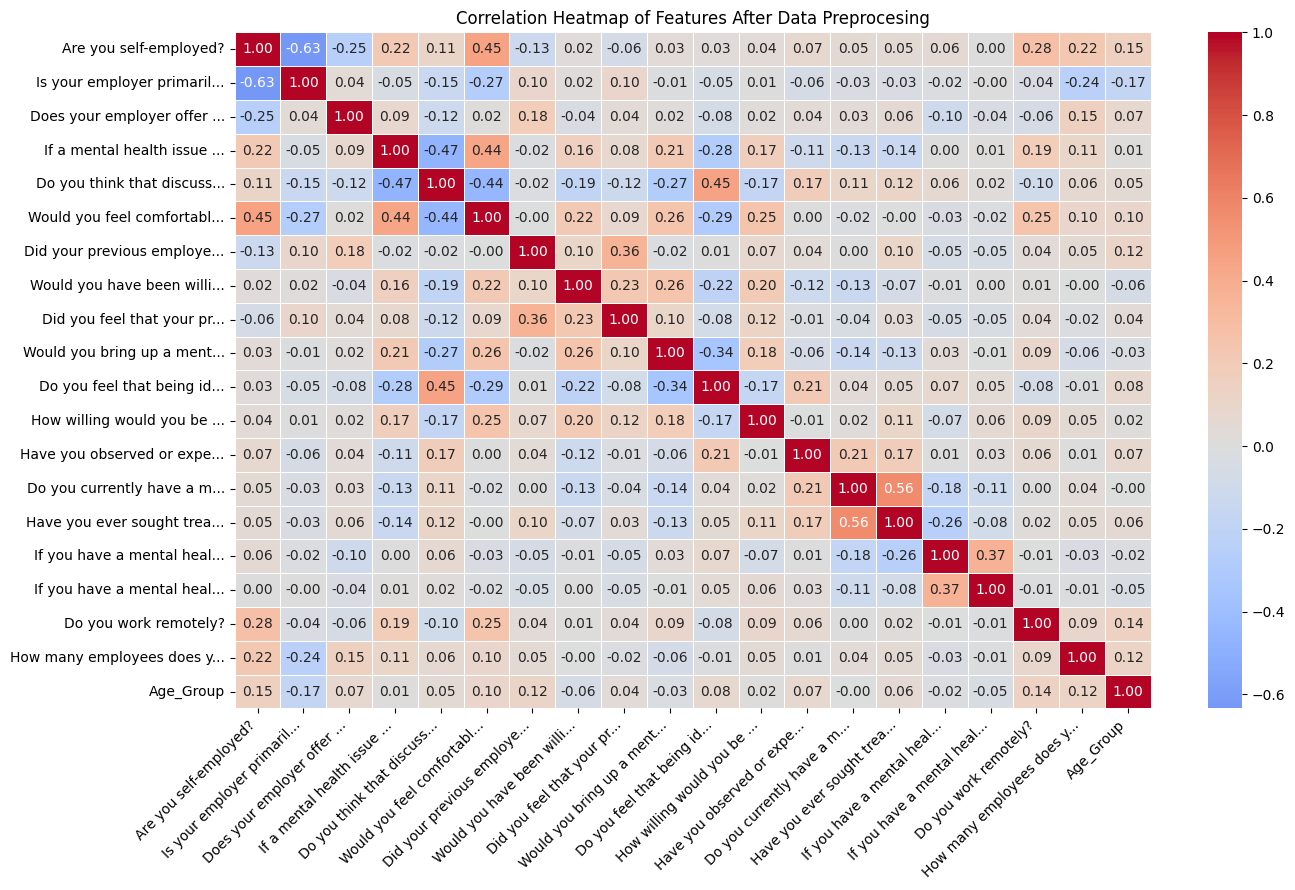

In [ ]:
# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot
plt.figure(figsize=(14, 9))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    xticklabels=feature_names_short,
    yticklabels=feature_names_short
)

plt.title("Correlation Heatmap of Features After Data Preprocesing")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# **Feature Selection**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import RobustScaler, StandardScaler


from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.metrics import silhouette_score
from sklearn import mixture

import random
import os


In [ ]:
# GLOBAL SEED CONTROL
np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 20 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   Are you self-employed?                                                                                                                      1433 non-null   float64
 1   Is your employer primarily a tech company/organization?                                                                                     1433 non-null   int64  
 2   Does your employer offer resources to learn more about mental health concerns and options for seeking help?                                 1433 non-null   float64
 3   If a mental health issue prompted you to re

In [ ]:
scaler = StandardScaler()

# Scale data
X_std_scaled = scaler.fit_transform(df)

# Convert back to DataFrame
X_std_scaled = pd.DataFrame(
    X_std_scaled,
    columns=df.columns
)

X_std_scaled.head()

,Are you self-employed?,Is your employer primarily a tech company/organization?,Does your employer offer resources to learn more about mental health concerns and options for seeking help?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Would you bring up a mental health issue with a potential employer in an interview?,Do you feel that being identified as a person with a mental health issue would hurt your career?,How willing would you be to share with friends and family that you have a mental illness?,Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?,Do you currently have a mental health disorder?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",Do you work remotely?,How many employees does your company or organization have?_mid,Age_Group
0,-0.500436,0.789225,-0.509143,1.29730,-1.283734,0.902987,-0.610515,0.408544,-0.664946,0.845573,-0.498585,0.346147,-0.655850,-1.173938,-1.188469,0.498147,0.592792,-0.010161,-0.388375,0.839737
1,-0.500436,0.789225,1.964084,0.42981,-1.283734,0.902987,1.239101,0.408544,1.192496,-0.726030,-1.953723,0.346147,-0.655850,1.103995,0.841419,-0.938159,-1.096017,-1.466197,-1.490952,-0.420308
2,-0.500436,0.789225,-0.509143,-0.43768,0.229087,-0.324698,1.239101,0.408544,-0.664946,2.417175,-0.498585,0.346147,-0.655850,-1.173938,0.841419,0.498147,0.592792,1.445875,-1.490952,0.839737
3,1.998257,-1.267065,-0.509143,0.42981,0.229087,0.902987,-0.610515,0.408544,-0.664946,0.845573,0.956553,-0.567350,-0.655850,1.103995,0.841419,0.498147,-1.096017,-0.010161,0.452620,0.839737
4,-0.500436,-1.267065,-0.509143,-0.43768,1.741908,-1.552384,-0.610515,0.408544,1.192496,-0.726030,0.956553,0.346147,1.524738,1.103995,0.841419,0.498147,-1.096017,-0.010161,-1.490952,0.839737


In [ ]:
X_std_scaled.describe()

,Are you self-employed?,Is your employer primarily a tech company/organization?,Does your employer offer resources to learn more about mental health concerns and options for seeking help?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Would you bring up a mental health issue with a potential employer in an interview?,Do you feel that being identified as a person with a mental health issue would hurt your career?,How willing would you be to share with friends and family that you have a mental illness?,Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?,Do you currently have a mental health disorder?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",Do you work remotely?,How many employees does your company or organization have?_mid,Age_Group
count,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03
mean,1.487528e-17,-1.090854e-16,5.950114e-17,-2.082540e-16,3.966742e-17,-1.338776e-16,2.479214e-17,1.735450e-17,-4.958428e-18,4.214664e-17,2.479214e-17,-7.437642e-18,5.206349e-17,-1.710658e-16,9.668935e-17,1.363568e-17,3.768405e-16,-6.941799e-17,1.834618e-16,-1.103250e-16
std,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00
min,-5.004361e-01,-1.267065e+00,-5.091431e-01,-2.172660e+00,-1.283734e+00,-1.552384e+00,-6.105152e-01,-1.403975e+00,-6.649464e-01,-7.260300e-01,-1.953723e+00,-2.394344e+00,-6.558504e-01,-1.173938e+00,-1.188469e+00,-2.374465e+00,-4.473635e+00,-1.466197e+00,-2.643587e+00,-1.680353e+00
25%,-5.004361e-01,-1.267065e+00,-5.091431e-01,-4.376799e-01,-1.283734e+00,-3.246984e-01,-6.105152e-01,-1.403975e+00,-6.649464e-01,-7.260300e-01,-4.985853e-01,-5.673499e-01,-6.558504e-01,-1.173938e+00,-1.188469e+00,-9.381593e-01,-1.096017e+00,-1.016075e-02,-3.883754e-01,-4.203082e-01
50%,-5.004361e-01,7.892253e-01,-5.091431e-01,4.298101e-01,2.290873e-01,-3.246984e-01,-6.105152e-01,4.085440e-01,-6.649464e-01,-7.260300e-01,-4.985853e-01,3.461472e-01,-6.558504e-01,-3.497176e-02,8.414189e-01,4.981466e-01,5.927920e-01,-1.016075e-02,4.336088e-01,-4.203082e-01
75%,-5.004361e-01,7.892253e-01,-5.091431e-01,4.298101e-01,2.290873e-01,9.029872e-01,1.239101e+00,4.085440e-01,1.192496e+00,8.455727e-01,9.565527e-01,3.461472e-01,1.524738e+00,1.103995e+00,8.414189e-01,4.981466e-01,5.927920e-01,-1.016075e-02,4.666132e-01,8.397371e-01
max,1.998257e+00,7.892253e-01,1.964084e+00,1.297300e+00,1.741908e+00,9.029872e-01,3.088717e+00,2.221063e+00,3.049939e+00,2.417175e+00,9.565527e-01,1.259644e+00,1.524738e+00,1.103995e+00,8.414189e-01,1.934452e+00,5.927920e-01,1.445875e+00,1.614630e+00,2.099782e+00


In [ ]:
X_std_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 20 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   Are you self-employed?                                                                                                                      1433 non-null   float64
 1   Is your employer primarily a tech company/organization?                                                                                     1433 non-null   float64
 2   Does your employer offer resources to learn more about mental health concerns and options for seeking help?                                 1433 non-null   float64
 3   If a mental health issue prompted you to re

**Using Mutual Information with GMM**

**Selecting best k**

k = 2, Silhouette = 0.0892, BIC = 43299.79
k = 3, Silhouette = 0.0957, BIC = 28853.75
k = 4, Silhouette = 0.0961, BIC = 21293.94
k = 5, Silhouette = 0.0938, BIC = 9040.97
k = 6, Silhouette = 0.0929, BIC = 10949.10
k = 7, Silhouette = 0.0609, BIC = 8820.45
k = 8, Silhouette = 0.0459, BIC = 47.97
k = 9, Silhouette = 0.0433, BIC = 2599.10
k = 10, Silhouette = 0.0326, BIC = 4464.68


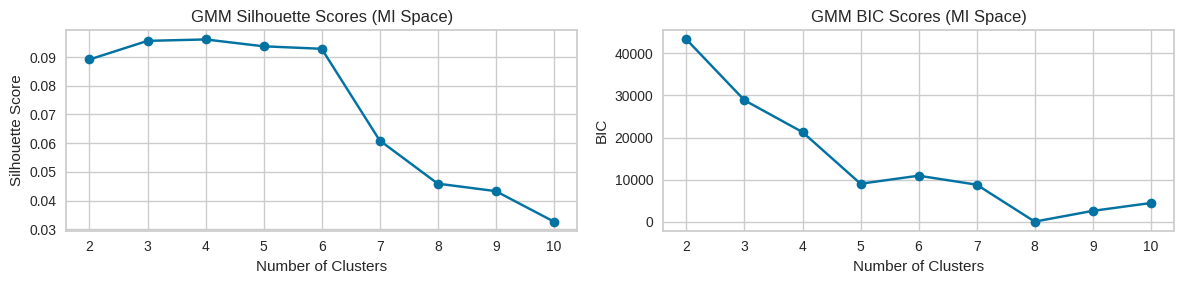

In [ ]:
silhouette_scores = []
bic_scores = []

n_clusters_range = range(2, 11)

for k in n_clusters_range:

    gmm = mixture.GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(X_std_scaled)

    cluster_labels = gmm.predict(X_std_scaled)

    # Silhouette
    sil_score = silhouette_score(
        X_std_scaled,
        cluster_labels
    )

    silhouette_scores.append(sil_score)

    # BIC
    bic_scores.append(gmm.bic(X_std_scaled))

    print(
        f"k = {k}, "
        f"Silhouette = {sil_score:.4f}, "
        f"BIC = {bic_scores[-1]:.2f}"
    )

# Side-by-side subplots

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 3)
)

# Silhouette plot
axes[0].plot(
    n_clusters_range,
    silhouette_scores,
    marker='o'
)

axes[0].set_title("GMM Silhouette Scores (MI Space)")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Silhouette Score")
axes[0].grid(True)

# BIC plot
axes[1].plot(
    n_clusters_range,
    bic_scores,
    marker='o'
)

axes[1].set_title("GMM BIC Scores (MI Space)")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("BIC")
axes[1].grid(True)

plt.tight_layout()
plt.show()

**We pick k= 4 for simplicity. We have two Ks becauase of Overlapping features. Although, both Ks are optimal**

**To use the MI for our features selection, we define a target variable using clusters**

In [ ]:
gmm = mixture.GaussianMixture(n_components=4, random_state=42)
y_cluster = gmm.fit_predict(X_std_scaled) # target variable

# Feature selection
k = 8
selector = SelectKBest(score_func=mutual_info_classif, k=k)

selector.fit(X_std_scaled, y_cluster)

# Selected features
selected_features = X_std_scaled.columns[selector.get_support()]

print(f"{k} selected features are:")
print(selected_features)

8 selected features are:
Index(['Are you self-employed?',
       'Is your employer primarily a tech company/organization?',
       'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:',
       'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?',
       'Would you bring up a mental health issue with a potential employer in an interview?',
       'Do you currently have a mental health disorder?',
       'Have you ever sought treatment for a mental health issue from a mental health professional?',
       'How many employees does your company or organization have?_mid'],
      dtype='object')


In [ ]:
feature_scores = pd.DataFrame({
    "Feature": X_std_scaled.columns,
    "MI Score": selector.scores_
}).sort_values(by="MI Score", ascending=False).reset_index(drop=True)

print(feature_scores)

                                              Feature  MI Score
0                              Are you self-employed?  0.490825
1   Have you ever sought treatment for a mental he...  0.390110
2   How many employees does your company or organi...  0.343709
3   Would you bring up a mental health issue with ...  0.313010
4   Is your employer primarily a tech company/orga...  0.245573
5   Would you feel comfortable discussing a mental...  0.189197
6   If a mental health issue prompted you to reque...  0.183302
7     Do you currently have a mental health disorder?  0.179536
8   If you have a mental health issue, do you feel...  0.174869
9   Do you think that discussing a mental health d...  0.149009
10  Does your employer offer resources to learn mo...  0.059444
11                              Do you work remotely?  0.056344
12  Did your previous employers provide resources ...  0.032275
13  Do you feel that being identified as a person ...  0.022177
14  Did you feel that your previous empl

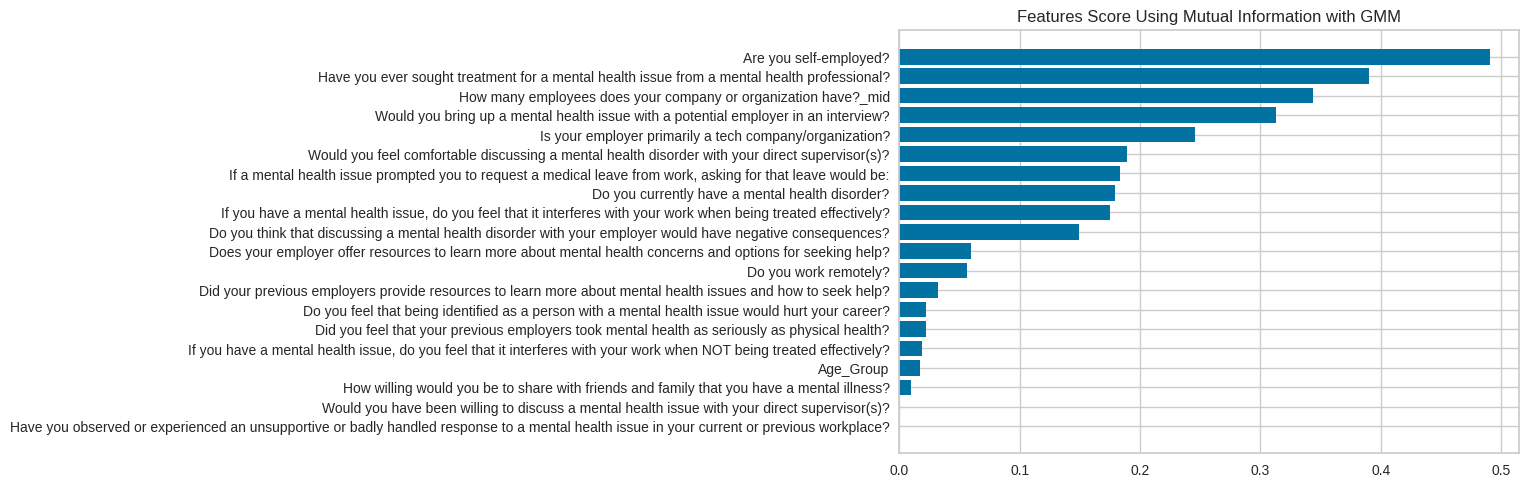

In [ ]:
score = feature_scores.head(len(X_std_scaled))

plt.barh(score["Feature"], score["MI Score"])
plt.gca().invert_yaxis()
plt.title("Features Score Using Mutual Information with GMM")
plt.show()

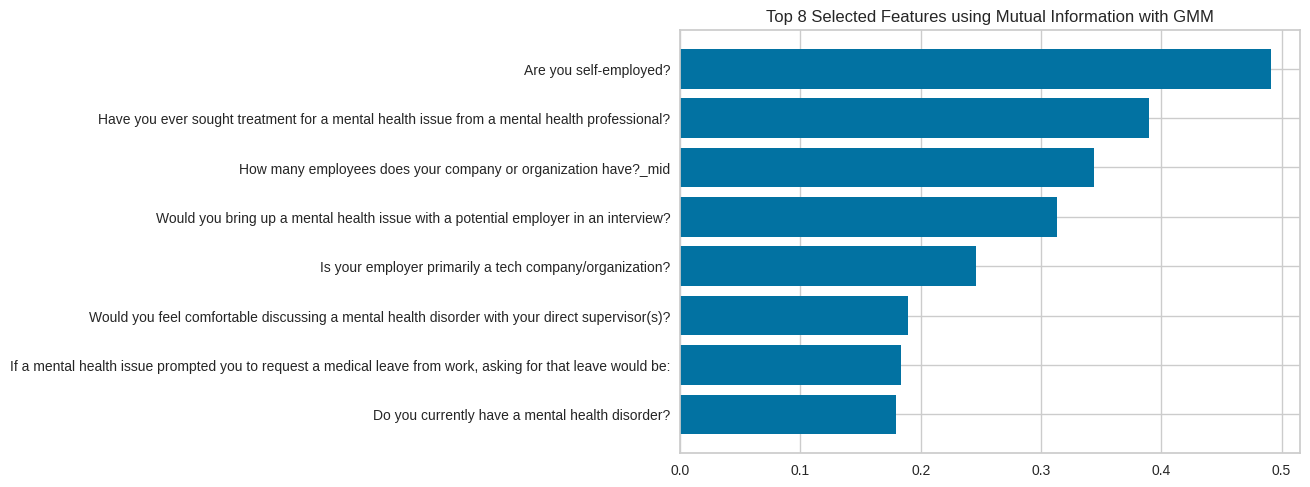

In [ ]:
top_score = feature_scores.head(len(selected_features)).reset_index(drop=True)

plt.barh(top_score["Feature"], top_score["MI Score"])
plt.gca().invert_yaxis()
plt.title(f"Top {len(selected_features)} Selected Features using Mutual Information with GMM")
plt.show()

In [ ]:
X_selected_df = pd.DataFrame(
    X_std_scaled,
    columns=selected_features
)

In [ ]:
# Shorten feature names
feature_names_short2 = [
    name[:25] + "..." if len(name) > 25 else name
    for name in X_selected_df.columns
]

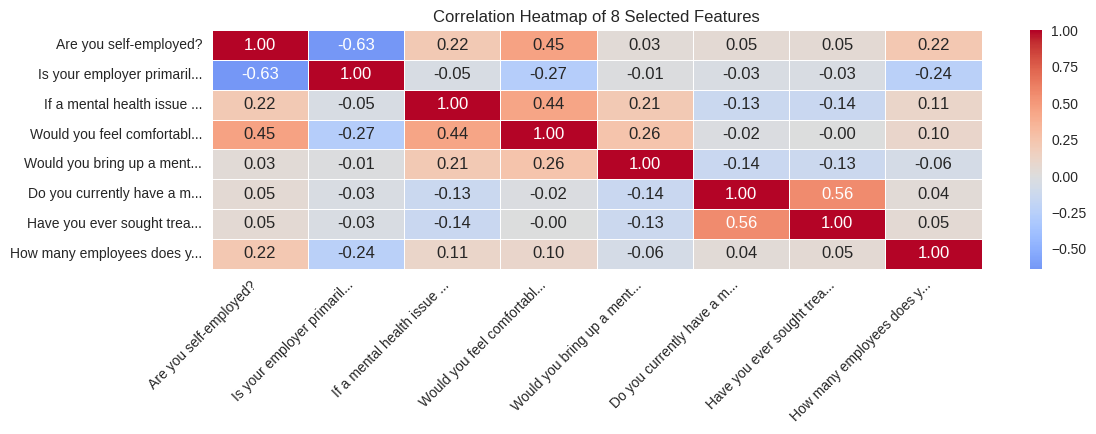

In [ ]:
# Correlation matrix
corr_matrix = X_selected_df.corr(numeric_only=True)

# Plot
plt.figure(figsize=(12, 4.5))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    xticklabels=feature_names_short2,
    yticklabels=feature_names_short2
)

plt.title(f"Correlation Heatmap of {len(selected_features)} Selected Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
X_selected_df.head(5)

,Are you self-employed?,Is your employer primarily a tech company/organization?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Would you bring up a mental health issue with a potential employer in an interview?,Do you currently have a mental health disorder?,Have you ever sought treatment for a mental health issue from a mental health professional?,How many employees does your company or organization have?_mid
0,-0.500436,0.789225,1.29730,0.902987,0.845573,-1.173938,-1.188469,-0.388375
1,-0.500436,0.789225,0.42981,0.902987,-0.726030,1.103995,0.841419,-1.490952
2,-0.500436,0.789225,-0.43768,-0.324698,2.417175,-1.173938,0.841419,-1.490952
3,1.998257,-1.267065,0.42981,0.902987,0.845573,1.103995,0.841419,0.452620
4,-0.500436,-1.267065,-0.43768,-1.552384,-0.726030,1.103995,0.841419,-1.490952


In [ ]:

X_selected_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 8 columns):
 #   Column                                                                                                       Non-Null Count  Dtype  
---  ------                                                                                                       --------------  -----  
 0   Are you self-employed?                                                                                       1433 non-null   float64
 1   Is your employer primarily a tech company/organization?                                                      1433 non-null   float64
 2   If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:  1433 non-null   float64
 3   Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?               1433 non-null   float64
 4   Would you bring up a mental health issue with a potential emp

In [ ]:
X_selected_df.describe()

,Are you self-employed?,Is your employer primarily a tech company/organization?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Would you bring up a mental health issue with a potential employer in an interview?,Do you currently have a mental health disorder?,Have you ever sought treatment for a mental health issue from a mental health professional?,How many employees does your company or organization have?_mid
count,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03,1.433000e+03
mean,1.487528e-17,-1.090854e-16,-2.082540e-16,-1.338776e-16,4.214664e-17,-1.710658e-16,9.668935e-17,1.834618e-16
std,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00
min,-5.004361e-01,-1.267065e+00,-2.172660e+00,-1.552384e+00,-7.260300e-01,-1.173938e+00,-1.188469e+00,-2.643587e+00
25%,-5.004361e-01,-1.267065e+00,-4.376799e-01,-3.246984e-01,-7.260300e-01,-1.173938e+00,-1.188469e+00,-3.883754e-01
50%,-5.004361e-01,7.892253e-01,4.298101e-01,-3.246984e-01,-7.260300e-01,-3.497176e-02,8.414189e-01,4.336088e-01
75%,-5.004361e-01,7.892253e-01,4.298101e-01,9.029872e-01,8.455727e-01,1.103995e+00,8.414189e-01,4.666132e-01
max,1.998257e+00,7.892253e-01,1.297300e+00,9.029872e-01,2.417175e+00,1.103995e+00,8.414189e-01,1.614630e+00


In [ ]:
X_selected_df.shape

(1433, 8)

# **Data Modelling and Visualization**

In [ ]:
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_pca_correlation_graph

from sklearn.manifold import MDS
from sklearn.preprocessing import MinMaxScaler

**Using GMM clustering**

Selecting optimal cluster (k)

 for k = 2, Score = 0.24, BIC = 510.84
 for k = 3, Score = 0.25, BIC = -17917.63
 for k = 4, Score = 0.20, BIC = -19213.53
 for k = 5, Score = 0.21, BIC = -28434.79
 for k = 6, Score = 0.20, BIC = -31976.87
 for k = 7, Score = 0.20, BIC = -33201.81
 for k = 8, Score = 0.17, BIC = -39500.77


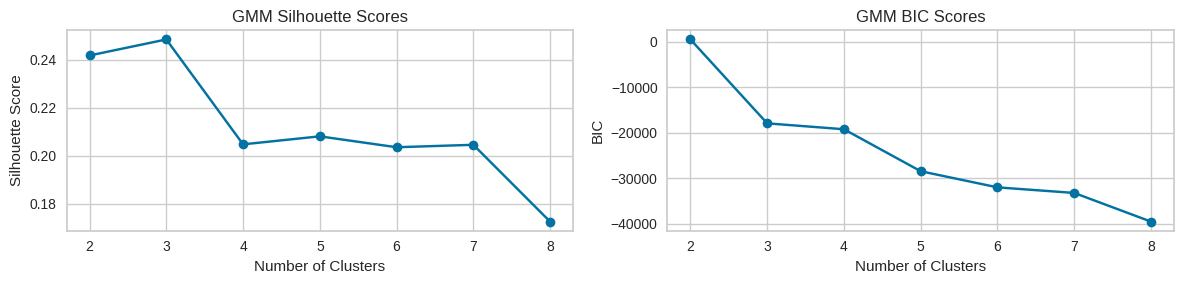

In [ ]:
silhouette_scores = []
bic_scores = []

n_clusters_range = range(2, 9)

for k in n_clusters_range:

    gmm = mixture.GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(X_selected_df)

    cluster_labels = gmm.predict(X_selected_df)

    # Silhouette
    sil_score = silhouette_score(
        X_selected_df,
        cluster_labels
    )

    silhouette_scores.append(sil_score)

    # BIC
    bic_scores.append(gmm.bic(X_selected_df))

    print(
        f" for k = {k}, "
        f"Score = {sil_score:.2f}, "
        f"BIC = {bic_scores[-1]:.2f}"
    )

# Side-by-side subplots

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 3)
)

# Silhouette plot
axes[0].plot(
    n_clusters_range,
    silhouette_scores,
    marker='o'
)

axes[0].set_title("GMM Silhouette Scores")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Silhouette Score")
axes[0].grid(True)

# BIC plot
axes[1].plot(
    n_clusters_range,
    bic_scores,
    marker='o'
)

axes[1].set_title("GMM BIC Scores")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("BIC")
axes[1].grid(True)

plt.tight_layout()
plt.show()

We select k = 3


In [ ]:
gmm = mixture.GaussianMixture(n_components=3)
# fit the model
gmm.fit(X_selected_df)
# extract the clusters predictions according to
# the highest probability
labels = gmm.predict(X_selected_df)

print(labels)

[2 0 2 ... 0 0 0]


In [ ]:
probs = gmm.predict_proba(X_selected_df)
print(probs)

[[0.00000000e+00 0.00000000e+00 1.00000000e+00]
 [9.99987930e-01 0.00000000e+00 1.20703419e-05]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]
 ...
 [9.99989776e-01 0.00000000e+00 1.02237745e-05]
 [9.99994107e-01 0.00000000e+00 5.89348584e-06]
 [9.99996522e-01 0.00000000e+00 3.47827151e-06]]


In [ ]:
# Adding clusters label
X_selected_df['Cluster'] = labels

In [ ]:
print("\nCluster Counts:\n")

print(X_selected_df['Cluster'].value_counts())


Cluster Counts:

Cluster
0    721
2    425
1    287
Name: count, dtype: int64


In [ ]:
cluster_summary = X_selected_df.groupby('Cluster').mean()

print("\nCluster Summary:\n")

print(cluster_summary)


Cluster Summary:

         Are you self-employed?  \
Cluster                           
0                     -0.500436   
1                      1.998257   
2                     -0.500436   

         Is your employer primarily a tech company/organization?  \
Cluster                                                            
0                                                 0.321498         
1                                                -1.267065         
2                                                 0.310231         

         If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:  \
Cluster                                                                                                                
0                                                -0.289689                                                             
1                                                 0.429810                                              

In [ ]:
X_selected_df.head(5)

,Are you self-employed?,Is your employer primarily a tech company/organization?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Would you bring up a mental health issue with a potential employer in an interview?,Do you currently have a mental health disorder?,Have you ever sought treatment for a mental health issue from a mental health professional?,How many employees does your company or organization have?_mid,Cluster
0,-0.500436,0.789225,1.29730,0.902987,0.845573,-1.173938,-1.188469,-0.388375,2
1,-0.500436,0.789225,0.42981,0.902987,-0.726030,1.103995,0.841419,-1.490952,0
2,-0.500436,0.789225,-0.43768,-0.324698,2.417175,-1.173938,0.841419,-1.490952,2
3,1.998257,-1.267065,0.42981,0.902987,0.845573,1.103995,0.841419,0.452620,1
4,-0.500436,-1.267065,-0.43768,-1.552384,-0.726030,1.103995,0.841419,-1.490952,0


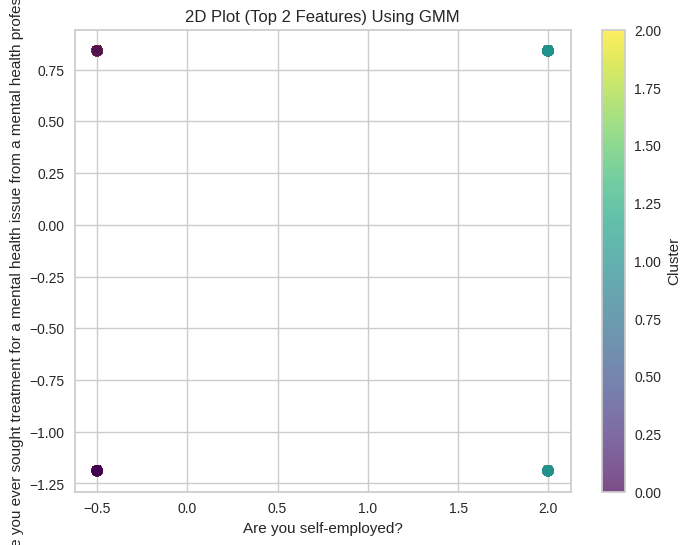

In [ ]:
# 2D Plot

top3_features = top_score.head(3)["Feature"].tolist()
top3_features

df_top = X_selected_df[top3_features]


plt.figure(figsize=(8,6))

plt.scatter(
    df_top[top3_features[0]],
    df_top[top3_features[1]],
    c=labels,   # add cluster labels
    cmap="viridis",
    alpha=0.7,
    s=60
)

plt.xlabel(top3_features[0])
plt.ylabel(top3_features[1])
plt.title("2D Plot (Top 2 Features) Using GMM")
plt.colorbar(label="Cluster")
plt.grid(True)

plt.show()

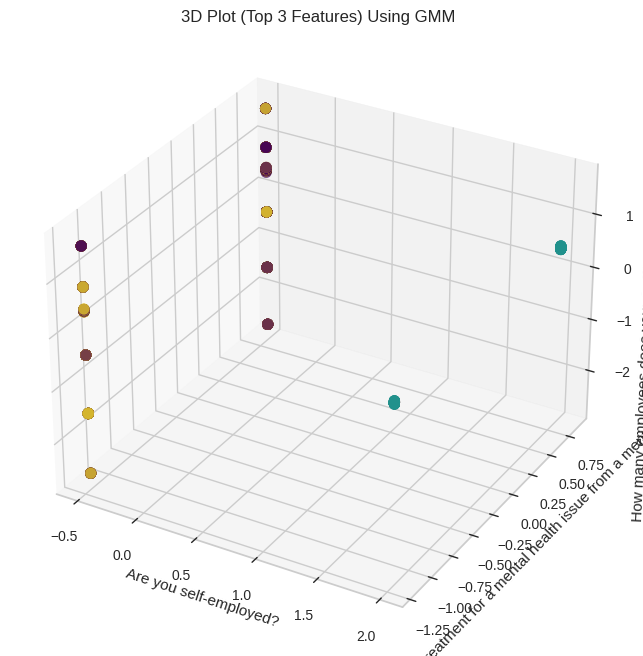

In [ ]:
# 3D Plot

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_top[top3_features[0]],
    df_top[top3_features[1]],
    df_top[top3_features[2]],
    c=labels,
    cmap="viridis",
    alpha=0.7,
    s=60
)

ax.set_xlabel(top3_features[0])
ax.set_ylabel(top3_features[1])
ax.set_zlabel(top3_features[2])
ax.set_title("3D Plot (Top 3 Features) Using GMM")

plt.show()

**Using PCA**

In [ ]:
X_selected = X_selected_df.drop(columns=["Cluster"])

In [ ]:
X_selected.head(5)

,Are you self-employed?,Is your employer primarily a tech company/organization?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Would you bring up a mental health issue with a potential employer in an interview?,Do you currently have a mental health disorder?,Have you ever sought treatment for a mental health issue from a mental health professional?,How many employees does your company or organization have?_mid
0,-0.500436,0.789225,1.29730,0.902987,0.845573,-1.173938,-1.188469,-0.388375
1,-0.500436,0.789225,0.42981,0.902987,-0.726030,1.103995,0.841419,-1.490952
2,-0.500436,0.789225,-0.43768,-0.324698,2.417175,-1.173938,0.841419,-1.490952
3,1.998257,-1.267065,0.42981,0.902987,0.845573,1.103995,0.841419,0.452620
4,-0.500436,-1.267065,-0.43768,-1.552384,-0.726030,1.103995,0.841419,-1.490952


In [ ]:
pca = PCA()

X_pca = pca.fit_transform(X_selected)

In [ ]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.27545395 0.21713672 0.14469847 0.11184136 0.09623628 0.06005501
 0.0541898  0.04038842]


In [ ]:
cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance)

[0.27545395 0.49259067 0.63728914 0.7491305  0.84536678 0.90542178
 0.95961158 1.        ]


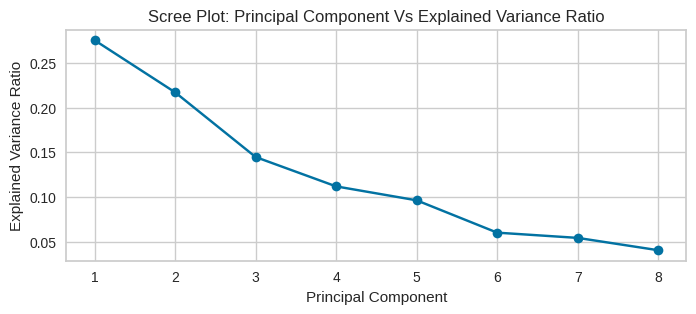

In [ ]:
plt.figure(figsize=(8,3))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker='o'
)

plt.xlabel("Principal Component")

plt.ylabel("Explained Variance Ratio")

plt.title("Scree Plot: Principal Component Vs Explained Variance Ratio")

plt.grid(True)

plt.show()

In [ ]:
# extract the eigenvectors
eig_vecs = pca.components_
eig_vecs

array([[ 0.545732  , -0.46231568,  0.36410138,  0.50268798,  0.1898501 ,
        -0.04480229, -0.03815265,  0.25232884],
       [ 0.18204215, -0.21572253, -0.26437059, -0.07350006, -0.32106252,
         0.59649202,  0.59581286,  0.17650367],
       [-0.18265026,  0.37194957,  0.35327003,  0.33560646,  0.46175604,
         0.36493622,  0.36944287, -0.32859684],
       [-0.25117124,  0.35580677,  0.42586085, -0.01087702, -0.20432157,
         0.02061883,  0.03578659,  0.76510499],
       [-0.1125115 , -0.12198487, -0.39576181, -0.20473749,  0.76067143,
         0.00512181,  0.0646206 ,  0.43714177],
       [-0.05084175,  0.29916622, -0.55728096,  0.70707022, -0.13919499,
        -0.23290516,  0.0835684 ,  0.12961708],
       [ 0.00754206, -0.07445423,  0.13839416, -0.1537991 , -0.00238322,
        -0.67357414,  0.70326316, -0.05749523],
       [ 0.7465176 ,  0.60403551, -0.07098426, -0.25225509,  0.08892641,
        -0.02476432, -0.00664319,  0.02481672]])

In [ ]:
# project the data to a two-dimensional feature space
X_projeted = PCA(n_components=3).fit(X_selected).transform(X_selected)

X_projeted

array([[ 0.44876647, -2.41907287,  0.79688571],
       [-0.62317077,  0.68844188,  1.7082613 ],
       [-0.85737344, -1.35991855,  1.60987761],
       ...,
       [-0.60787622,  0.88461873, -0.09641732],
       [ 0.36919647,  0.79815825, -1.19553108],
       [-1.51445606,  0.67414384, -1.14917213]])

In [ ]:
feature_names = X_selected.columns.tolist()

feature_names

['Are you self-employed?',
 'Is your employer primarily a tech company/organization?',
 'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:',
 'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?',
 'Would you bring up a mental health issue with a potential employer in an interview?',
 'Do you currently have a mental health disorder?',
 'Have you ever sought treatment for a mental health issue from a mental health professional?',
 'How many employees does your company or organization have?_mid']

                                 Dim 1     Dim 2     Dim 3
Are you self-employed?       -0.810119 -0.239929  0.196516
Is your employer primaril...  0.686291  0.284320 -0.400185
If a mental health issue ... -0.540495  0.348437 -0.380088
Would you feel comfortabl... -0.746222  0.096872 -0.361083
Would you bring up a ment... -0.281826  0.423157 -0.496809
Do you currently have a m...  0.066507 -0.786170 -0.392639
Have you ever sought trea...  0.056636 -0.785275 -0.397488
How many employees does y... -0.374573 -0.232630  0.353541


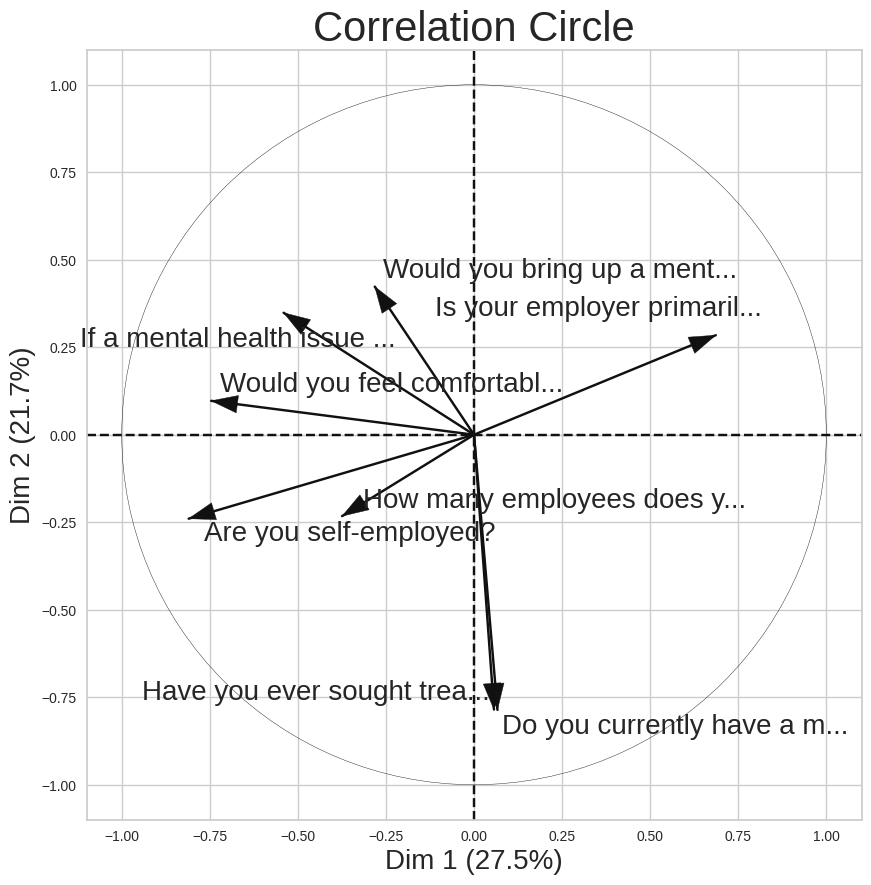

In [ ]:
fig, cor_mat = plot_pca_correlation_graph(
    X_selected,
    feature_names_short2,
    dimensions=(1, 2, 3),
    figure_axis_size=10
)

print(cor_mat)

/tmp/ipykernel_4307/827282731.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


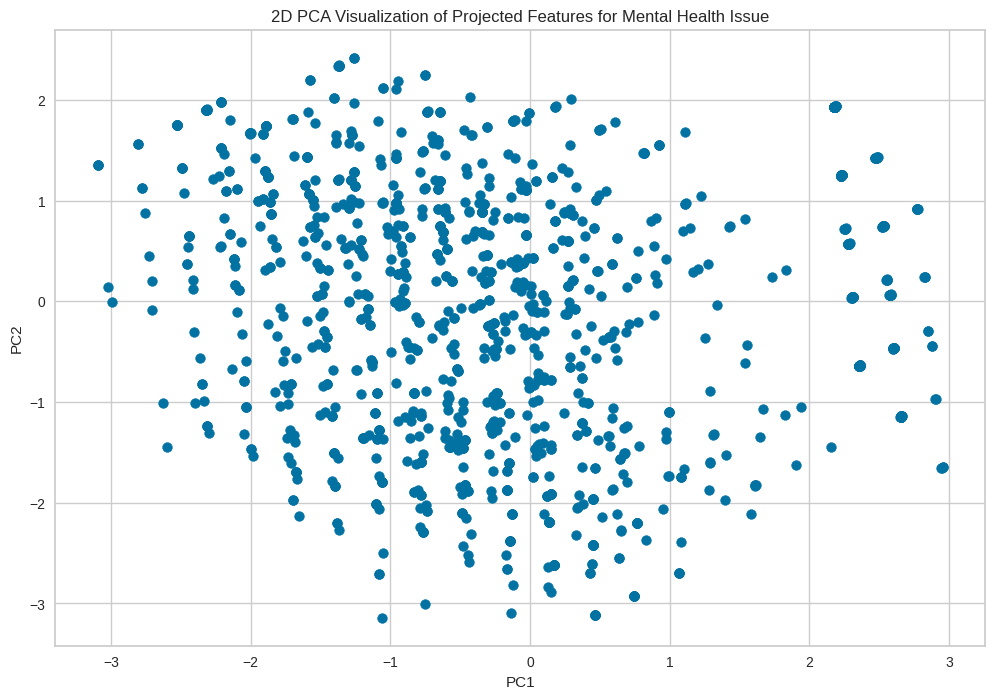

In [ ]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    X_projeted[:, 0],   # PC1
    X_projeted[:, 1],   # PC2
    cmap="viridis",
    s=50
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Visualization of Projected Features for Mental Health Issue")


plt.show()

/tmp/ipykernel_4307/2593660217.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


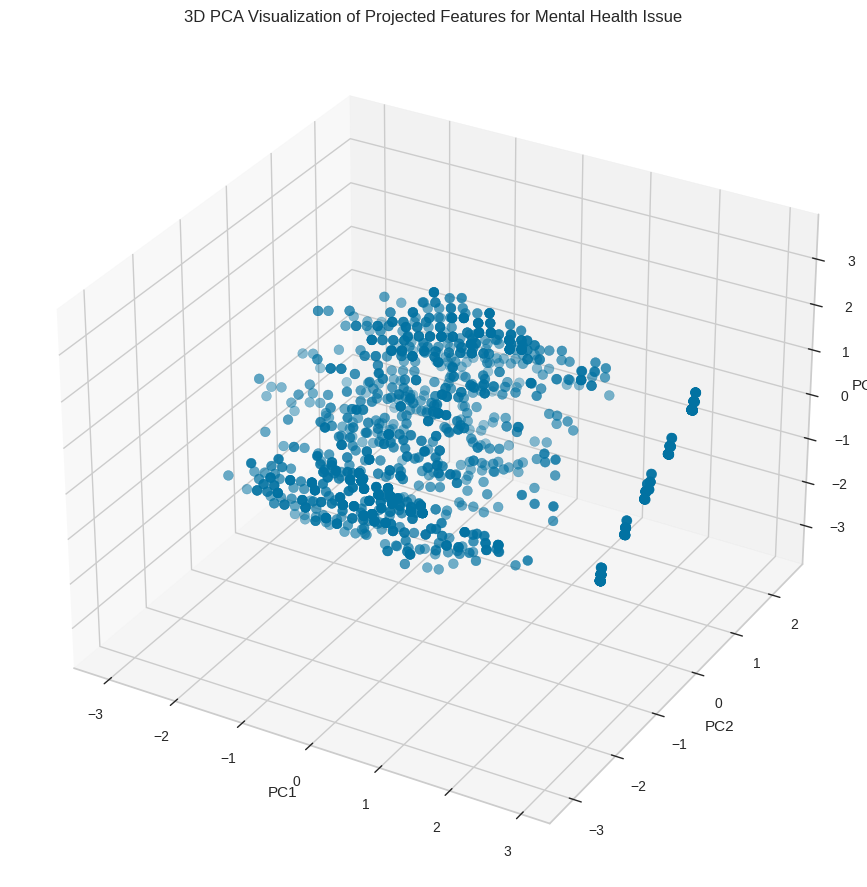

In [ ]:
fig = plt.figure(figsize=(16, 11))
ax = fig.add_subplot(111, projection='3d')


scatter = ax.scatter(
    X_projeted[:, 0],   # PC1
    X_projeted[:, 1],   # PC2
    X_projeted[:, 2],   # PC3
    cmap='viridis',
    s=50
)


ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Visualization of Projected Features for Mental Health Issue")


plt.show()

**Using PCA + GMM**

Selecting optimal K

for k = 2, score = 0.22, BIC = 12912.28
for k = 3, score = 0.31, BIC = 10042.15
for k = 4, score = 0.25, BIC = 9329.15
for k = 5, score = 0.27, BIC = 8693.80
for k = 6, score = 0.17, BIC = 7833.51
for k = 7, score = 0.15, BIC = 7948.82
for k = 8, score = 0.12, BIC = 7933.56


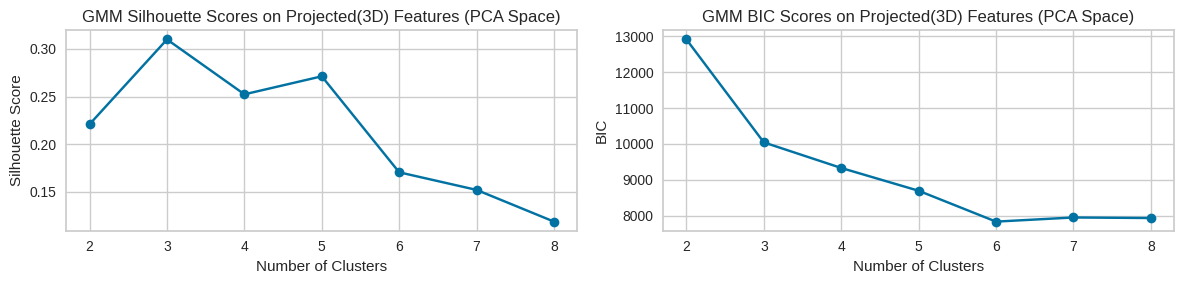

In [ ]:
silhouette_scores = []
bic_scores = []

n_clusters_range = range(2, 9)

for k in n_clusters_range:

    gmm = mixture.GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(X_projeted)

    cluster_labels = gmm.predict(X_projeted)

    # Silhouette
    sil_score = silhouette_score(
        X_projeted,
        cluster_labels
    )

    silhouette_scores.append(sil_score)

    # BIC
    bic_scores.append(gmm.bic(X_projeted))

    print(
        f"for k = {k}, "
        f"score = {sil_score:.2f}, "
        f"BIC = {bic_scores[-1]:.2f}"
    )

# Side-by-side subplots

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 3)
)

# Silhouette plot
axes[0].plot(
    n_clusters_range,
    silhouette_scores,
    marker='o'
)

axes[0].set_title("GMM Silhouette Scores on Projected(3D) Features (PCA Space)")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Silhouette Score")
axes[0].grid(True)

# BIC plot
axes[1].plot(
    n_clusters_range,
    bic_scores,
    marker='o'
)

axes[1].set_title("GMM BIC Scores on Projected(3D) Features (PCA Space)")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("BIC")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
gmm = mixture.GaussianMixture(n_components=3)
# fit the model
gmm.fit(X_projeted)
# extract the clusters predictions according to
# the highest probability
labels = gmm.predict(X_projeted)

print(labels)

[0 1 0 ... 0 0 0]


In [ ]:
X_projected_df = pd.DataFrame(
    X_projeted,
    columns=["PC1", "PC2", "PC3"]
)

X_projected_df.head(5)

,PC1,PC2,PC3
0,0.448766,-2.419073,0.796886
1,-0.623171,0.688442,1.708261
2,-0.857373,-1.359919,1.609878
3,2.479890,1.425362,0.574083
4,-1.222655,1.541839,-0.187072


In [ ]:
# Adding clusters label
X_projected_df['Cluster'] = labels

X_projected_df.head(5)

,PC1,PC2,PC3,Cluster
0,0.448766,-2.419073,0.796886,0
1,-0.623171,0.688442,1.708261,1
2,-0.857373,-1.359919,1.609878,0
3,2.479890,1.425362,0.574083,2
4,-1.222655,1.541839,-0.187072,1


In [ ]:
X_projected_df.tail(5)

,PC1,PC2,PC3,Cluster
1428,2.280006,0.568678,-0.978263,2
1429,2.366037,-0.634750,-1.739371,2
1430,-0.607876,0.884619,-0.096417,0
1431,0.369196,0.798158,-1.195531,0
1432,-1.514456,0.674144,-1.149172,0


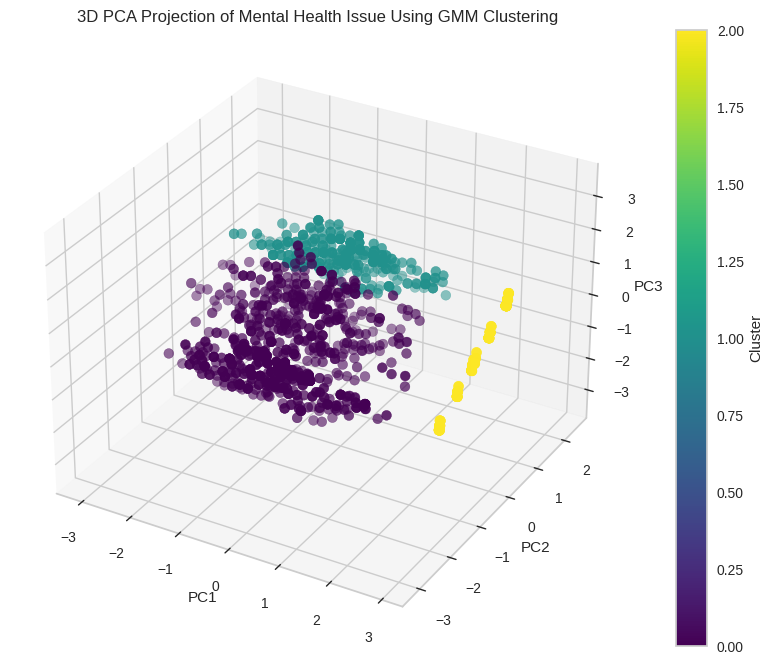

In [ ]:
fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111, projection='3d')


scatter = ax.scatter(
    X_projeted[:, 0],   # PC1
    X_projeted[:, 1],   # PC2
    X_projeted[:, 2],   # PC3
    c=X_projected_df['Cluster'],  # cluster labels
    cmap='viridis',
    s=50
)


ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection of Mental Health Issue Using GMM Clustering")


plt.colorbar(scatter, label="Cluster")

plt.show()

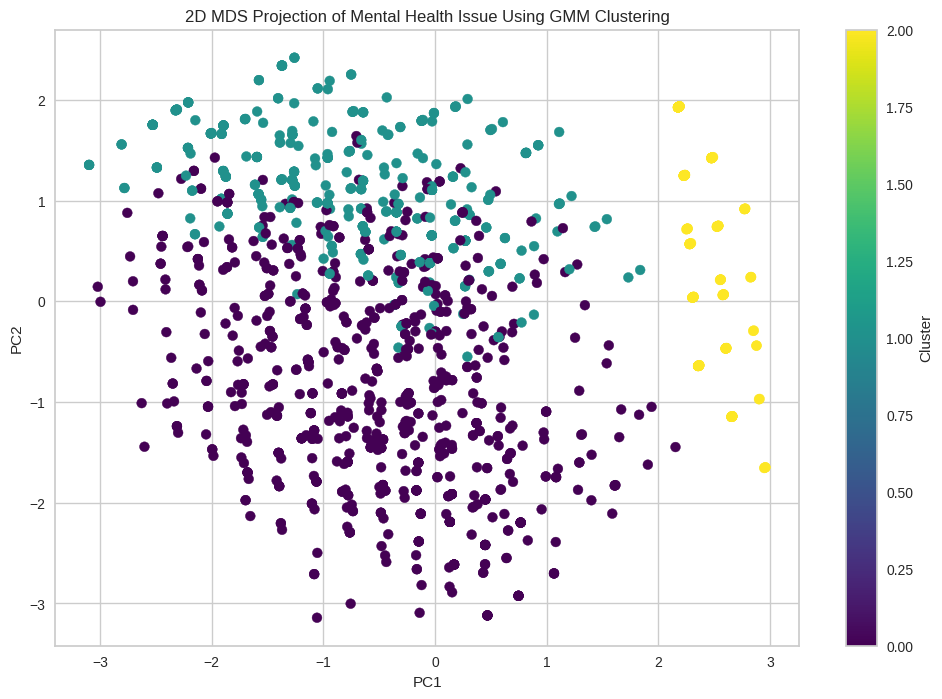

In [ ]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    X_projeted[:, 0],   # PC1
    X_projeted[:, 1],   # PC2
    c=X_projected_df["Cluster"],
    cmap="viridis",
    s=50
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D MDS Projection of Mental Health Issue Using GMM Clustering")

plt.colorbar(scatter, label="Cluster")

plt.show()

In [ ]:
centroids = X_projected_df.groupby("Cluster")[["PC1", "PC2","PC3"]].mean().reset_index()

In [ ]:
print("The Cluster summary is:")
centroids

The Cluster summary is:


,Cluster,PC1,PC2,PC3
0,0,-0.511439,-0.864070,-0.214696
1,1,-0.767186,1.133139,0.692215
2,2,2.403089,0.631897,-0.422499


**Using MDS and GMM**

**We do this using the 8 selected features (columns=selected_features) from above df**

In [ ]:
X_mds_df = pd.DataFrame(
    df,
    columns=selected_features
)

X_mds_df.head(5)

,Are you self-employed?,Is your employer primarily a tech company/organization?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Would you bring up a mental health issue with a potential employer in an interview?,Do you currently have a mental health disorder?,Have you ever sought treatment for a mental health issue from a mental health professional?,How many employees does your company or organization have?_mid
0,0.0,1,4,1.0,0.5,0.0,0.0,4.158883
1,0.0,1,3,1.0,0.0,1.0,1.0,2.803360
2,0.0,1,2,0.5,1.0,0.0,1.0,2.803360
3,1.0,0,3,1.0,0.5,1.0,1.0,5.192815
4,0.0,0,2,0.0,0.0,1.0,1.0,2.803360


In [ ]:
# normalizing the data

X_mm_scaled = MinMaxScaler().fit_transform(X_mds_df)

In [ ]:
X_mm_scaled

array([[0.        , 1.        , 1.        , ..., 0.        , 0.        ,
        0.52961409],
       [0.        , 1.        , 0.75      , ..., 1.        , 1.        ,
        0.27068498],
       [0.        , 1.        , 0.5       , ..., 0.        , 1.        ,
        0.27068498],
       ...,
       [0.        , 1.        , 0.25      , ..., 0.5       , 1.        ,
        0.82535321],
       [0.        , 0.        , 0.25      , ..., 1.        , 0.        ,
        0.82535321],
       [0.        , 1.        , 0.        , ..., 1.        , 0.        ,
        0.82535321]])

In [ ]:
# reducing to different numbers of dimensions
# and extract the stress values
for k in range(1,len(selected_features)+1):
  mds = MDS(k, random_state=42)
  mds_fit = mds.fit_transform(X_mm_scaled)
  print('Stress with ' + str(k) + ' dim: '
  + str(mds.stress_.round(2)))

Stress with 1 dimensions: 722693.89
Stress with 2 dimensions: 139484.37
Stress with 3 dimensions: 48366.08
Stress with 4 dimensions: 22604.71
Stress with 5 dimensions: 10274.66
Stress with 6 dimensions: 4648.42
Stress with 7 dimensions: 1540.0
Stress with 8 dimensions: 31.1


In [ ]:
# conduct MDS on the data
mds = MDS(3, random_state=42)
X_3d = mds.fit_transform(X_mm_scaled)

In [ ]:
X_3d

array([[ 0.09389622, -0.9305211 , -0.52731826],
       [ 0.51204647,  0.6483017 , -0.48689211],
       [ 1.00032426, -0.28902243, -0.63715169],
       ...,
       [ 0.43905765,  0.28810557, -0.32789099],
       [-0.84660279, -0.00348538,  0.7343985 ],
       [ 0.34135639, -0.14460332,  1.00226591]])

In [ ]:
mds_df = pd.DataFrame(
    X_3d,
    columns=["MDS1", "MDS2", "MDS3"]
)

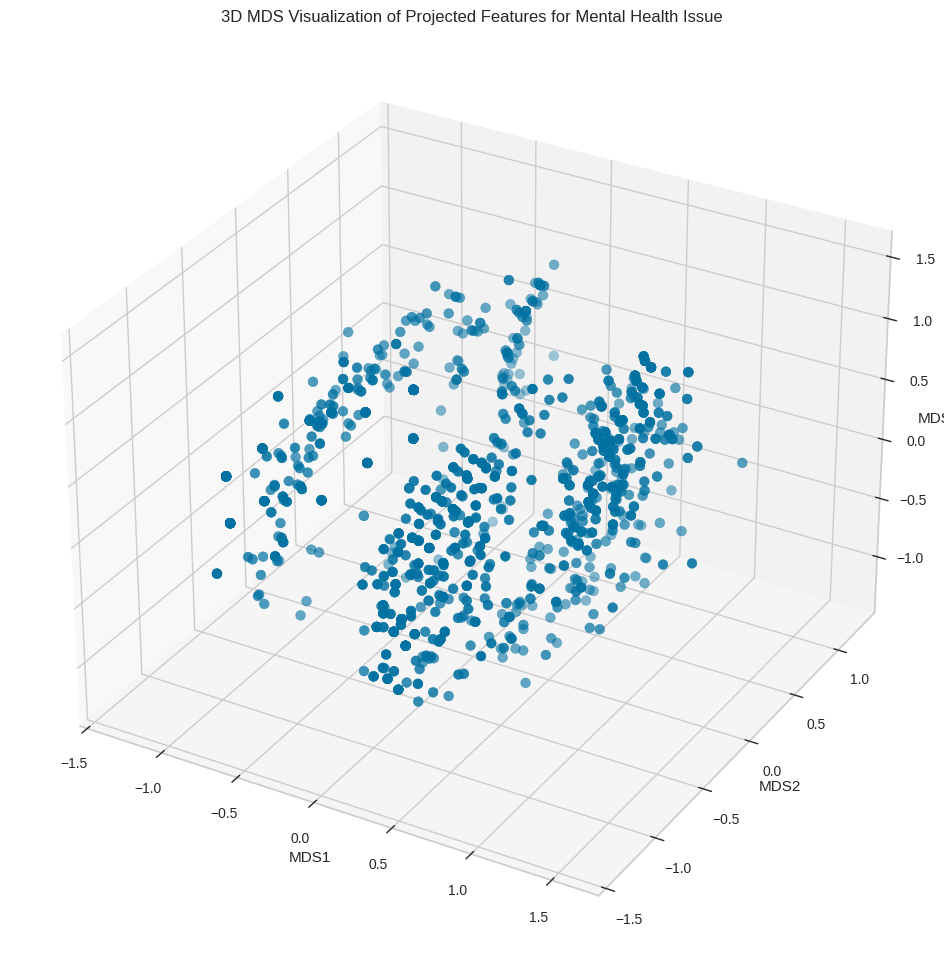

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    mds_df.iloc[:, 0],  # MDS1
    mds_df.iloc[:, 1],  # MDS2
    mds_df.iloc[:, 2],  # MDS3
    s=50
)

ax.set_xlabel("MDS1")
ax.set_ylabel("MDS2")
ax.set_zlabel("MDS3")
ax.set_title("3D MDS Visualization of Projected Features for Mental Health Issue")

plt.show()

for k = 2, score = 0.34, BIC = 6985.47
for k = 3, score = 0.37, BIC = 6453.79
for k = 4, score = 0.36, BIC = 5829.95
for k = 5, score = 0.28, BIC = 5092.38
for k = 6, score = 0.31, BIC = 5175.13
for k = 7, score = 0.28, BIC = 4887.39
for k = 8, score = 0.38, BIC = 4946.91


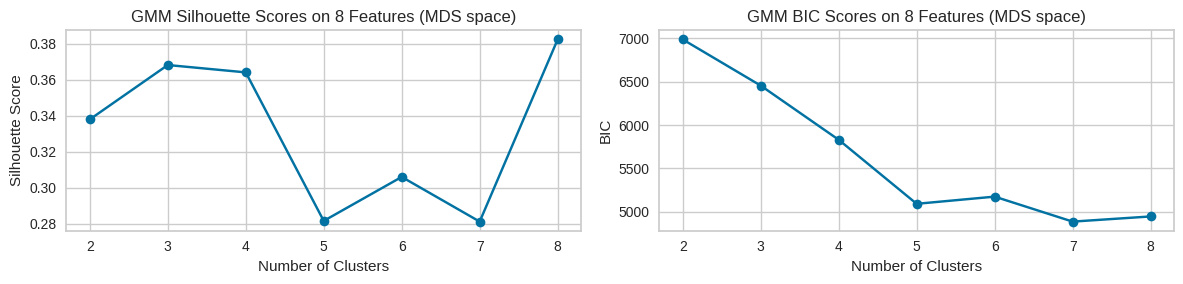

In [ ]:
silhouette_scores = []
bic_scores = []

n_clusters_range = range(2, 9)

for k in n_clusters_range:

    gmm = mixture.GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(mds_df)

    cluster_labels = gmm.predict(mds_df)

    # Silhouette
    sil_score = silhouette_score(mds_df, cluster_labels)
    silhouette_scores.append(sil_score)

    # BIC
    bic_scores.append(gmm.bic(mds_df))

    print(
        f"for k = {k}, "
        f"score = {sil_score:.2f}, "
        f"BIC = {bic_scores[-1]:.2f}"
    )


# Subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Silhouette
axes[0].plot(n_clusters_range, silhouette_scores, marker='o')
axes[0].set_title(f"GMM Silhouette Scores on {len(selected_features)} Features (MDS space)")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Silhouette Score")
axes[0].grid(True)

# BIC
axes[1].plot(n_clusters_range, bic_scores, marker='o')
axes[1].set_title(f"GMM BIC Scores on {len(selected_features)} Features (MDS space)")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("BIC")
axes[1].grid(True)

plt.tight_layout()
plt.show()

**We pick k=3 for simplicity. However according to the Silhouette Scores of k = 3 is 0.368 (second best) which is closed to optimal k=8 (0.383)**

In [ ]:
# For 3D
gmm = mixture.GaussianMixture(
    n_components=3,
    random_state=42
)

clusters = gmm.fit_predict(mds_df)

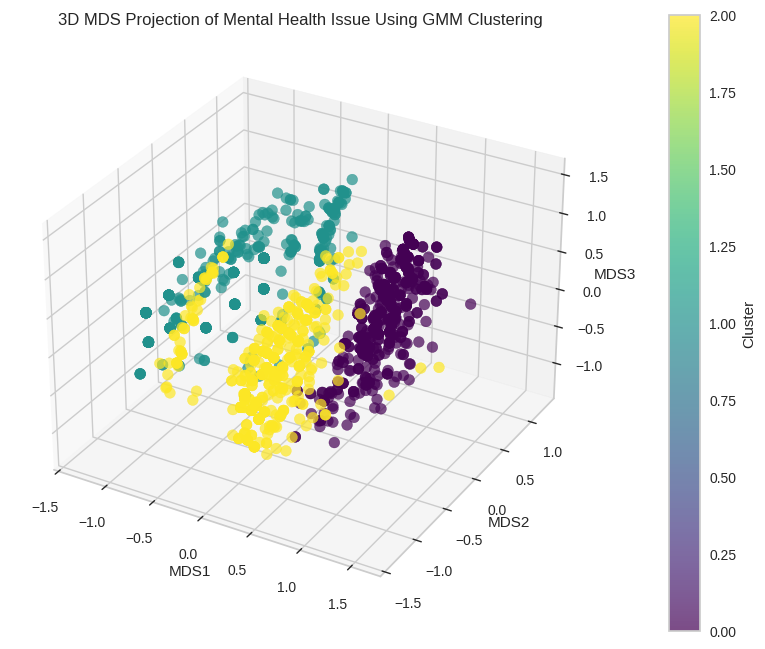

In [ ]:
# Add cluster labels
mds_df["Cluster"] = clusters

# 3D Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    mds_df["MDS1"],
    mds_df["MDS2"],
    mds_df["MDS3"],
    c=mds_df["Cluster"],     # color by cluster
    cmap="viridis",          # adding color map
    s=60,                    # marker size
    alpha=0.7
)

# Axis labels
ax.set_title("3D MDS Projection of Mental Health Issue Using GMM Clustering")
ax.set_xlabel("MDS1")
ax.set_ylabel("MDS2")
ax.set_zlabel("MDS3")

# Color bar
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label("Cluster")

plt.show()

In [ ]:
centroids_MDS = mds_df.groupby("Cluster")[["MDS1", "MDS2","MDS3"]].mean().reset_index()

print("The Cluster summary is:")
centroids_MDS

The Cluster summary is:


,Cluster,MDS1,MDS2,MDS3
0,0,0.595800,0.393561,-0.087184
1,1,-0.792243,0.281846,0.031821
2,2,0.201261,-0.820191,0.070115


**conduct MDS on the data for 2D**

In [ ]:
mds2 = MDS(2, random_state=42)
X_2 = mds2.fit_transform(X_mm_scaled)

In [ ]:
mds_df2 = pd.DataFrame(
    X_2,
    columns=["MDS1", "MDS2",]
)

/tmp/ipykernel_4307/4025692743.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


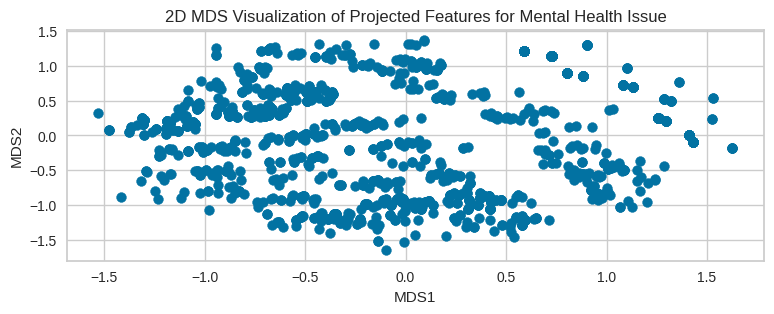

In [ ]:
plt.figure(figsize=(9, 3))

scatter = plt.scatter(
    mds_df2.iloc[:, 0],   # MDS1
    mds_df2.iloc[:, 1],   # MDS2
    cmap="viridis",
    s=50
)

plt.xlabel("MDS1")
plt.ylabel("MDS2")
plt.title("2D MDS Visualization of Projected Features for Mental Health Issue")


plt.show()

In [ ]:
gmm = mixture.GaussianMixture(
    n_components=3,
    random_state=42
)

clusters = gmm.fit_predict(mds_df2)

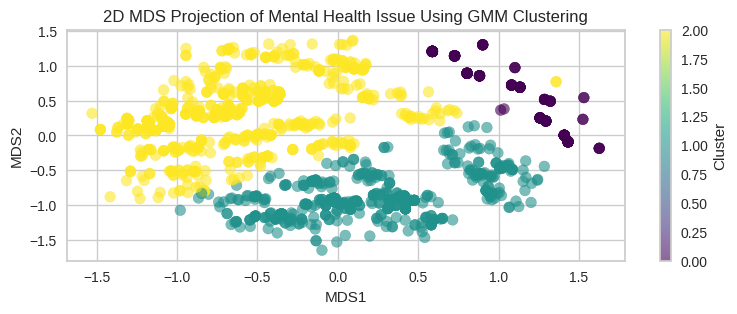

In [ ]:
# Add cluster labels
mds_df2["Cluster"] = clusters


plt.figure(figsize=(9,3))

scatter = plt.scatter(
    mds_df2["MDS1"],
    mds_df2["MDS2"],
    c=mds_df2["Cluster"],
    cmap="viridis",
    s=60,
    alpha=0.6
)

plt.title("2D MDS Projection of Mental Health Issue Using GMM Clustering")
plt.xlabel("MDS1")
plt.ylabel("MDS2")
plt.grid(True)

# Color bar
plt.colorbar(scatter, label="Cluster")

plt.show()

In [ ]:
centroids_MDS2 = mds_df2.groupby("Cluster")[["MDS1", "MDS2"]].mean().reset_index()

print("The Cluster summary is:")
centroids_MDS2

The Cluster summary is:


,Cluster,MDS1,MDS2
0,0,0.991716,0.696555
1,1,0.226951,-0.861401
2,2,-0.586047,0.313606
